# Analysis and figures
for Ensembles 1-4

In [1]:
%load_ext autoreload
%autoreload 2
import logging
import math
import os
import pathlib

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr
from invert4geom import utils
from polartoolkit import utils as polar_utils

import synthetic_bathymetry_inversion.plotting as synth_plotting
from synthetic_bathymetry_inversion import ice_shelf_stats, synthetic

os.environ["POLARTOOLKIT_HEMISPHERE"] = "south"

sns.set_theme()

logging.getLogger().setLevel(logging.INFO)

/home/sungw937/miniforge3/envs/synthetic_bathymetry_inversion/lib/python3.12/site-packages/UQpy/__init__.py:6: UserWarning:

pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



In [2]:
# set grid parameters
spacing = 2e3
inversion_region = (-40e3, 110e3, -1600e3, -1400e3)

plot_region = inversion_region

true_density_contrast = 1476

bathymetry, _, _ = synthetic.load_synthetic_model(
    spacing=spacing,
    inversion_region=inversion_region,
    buffer=spacing * 10,
    zref=0,
    bathymetry_density_contrast=true_density_contrast,
    plot_topography=False,
    plot_gravity=False,
)

buffer_region = polar_utils.get_grid_info(bathymetry)[1]

# clip to inversion region
bathymetry = bathymetry.sel(
    easting=slice(plot_region[0], plot_region[1]),
    northing=slice(plot_region[2], plot_region[3]),
)

requested spacing (2000.0) is smaller than the original (5000.0).


  0%|          | 0/7676 [00:00<?, ?it/s]

In [3]:
# get list of all Antarctic ice shelves
ice_shelves = ice_shelf_stats.get_ice_shelves()

print(f"Number of ice shelves: {len(ice_shelves)}")

ice_shelves

Number of ice shelves: 164


,NAME,Regions,TYPE,geometry,area_km
0,Ross,West,FL,"POLYGON ((-240677.184 -678259.006, -240038.274...",480428.37
1,Ronne_Filchner,West,FL,"POLYGON ((-1006734.891 880592.98, -1006335.923...",427041.70
2,Amery,East,FL,"POLYGON ((2134701.422 618463.117, 2131452.011 ...",60797.28
3,LarsenC,Peninsula,FL,"POLYGON ((-2235724.269 1271352.188, -2235828.5...",47443.51
4,Riiser-Larsen,East,FL,"POLYGON ((-592166.317 1592824.258, -593783.16 ...",42913.14
...,...,...,...,...,...
159,Perkins,West,FL,"POLYGON ((-1129608.753 -1201300.734, -1130034....",7.01
160,Paternostro,East,FL,"POLYGON ((824294.485 -2115301.607, 823916.673 ...",6.55
161,Arneb,East,FL,"POLYGON ((333867.825 -1897953.452, 333673.461 ...",6.41
162,Falkner,East,FL,"POLYGON ((425350.532 -1726631.609, 423726.753 ...",5.69


In [113]:
# get gravity and constraint spacing stats on ice shelves
ice_shelf_stats_gdf = pd.read_csv(
    "../results/ice_shelves/ice_shelf_gravity_stats.csv", index_col=None
)
ice_shelf_stats_gdf

,NAME,Regions,TYPE,geometry,area_km,median_constraint_distance,mean_constraint_distance,max_constraint_distance,constraint_proximity_skewness,gravity_disturbance_rms,...,reg_rms,reg_stdev,res_rms,res_stdev,error_rms,error_stdev,residual_constraint_proximity_ratio_rms,residual_constraint_proximity_ratio_stdev,regional_constraint_proximity_ratio_rms,regional_constraint_proximity_ratio_stdev
0,Ross,West,FL,POLYGON ((-240677.18377991652 -678259.00593521...,480428.37,17.282824,17.636882,62.339089,0.431810,44.934094,...,17.652465,17.159272,6.399599,6.397548,12.748633,3.154937,132.093296,132.083718,306.642616,292.262320
1,Ronne_Filchner,West,FL,POLYGON ((-1006734.8906412432 880592.979674786...,427041.70,7.686515,8.739788,46.338298,1.456174,41.514238,...,34.036735,20.853880,4.087359,4.084574,7.952294,1.760702,60.063692,60.065236,350.615365,251.773078
2,Amery,East,FL,POLYGON ((2134701.4219642165 618463.1172190169...,60797.28,16.941666,21.373582,74.852666,0.844014,54.656450,...,41.754702,25.626999,15.490488,12.651456,8.432001,0.497149,516.984001,453.747317,1173.773769,858.199460
3,LarsenC,Peninsula,FL,POLYGON ((-2235724.269360441 1271352.187501361...,47443.51,9.067471,10.260593,36.855613,0.763313,14.824574,...,38.595139,14.498270,5.654761,5.647546,5.735885,1.390208,69.319708,69.157083,508.573512,329.301767
4,Riiser-Larsen,East,FL,POLYGON ((-592166.3173854565 1592824.257663729...,42913.14,17.664812,20.596557,63.202992,0.713248,53.556828,...,80.002938,41.235478,11.714963,11.313144,8.285409,0.728764,400.456039,396.959121,1942.610309,1289.222243
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,Drury,East,FL,"POLYGON ((895410.318218497 -2105991.070752478,...",55.61,3.143890,3.746163,9.463699,0.496175,85.931453,...,62.911283,0.391773,1.065483,0.188445,12.959736,0.030865,5.806477,2.009965,373.109779,180.049402
123,Zelee,East,FL,POLYGON ((1595256.149328336 -1990608.354406229...,40.65,2.835378,2.856841,6.070070,0.102221,56.605168,...,46.436621,16.304421,3.328922,2.252083,6.485042,1.849987,13.854037,12.595032,108.332900,58.853888
124,Dalk,East,FL,POLYGON ((2199011.8758713417 527659.2832139434...,35.44,1.102750,1.103613,2.569476,0.153243,9.456864,...,7.182482,2.665939,3.898634,3.898634,8.295042,0.233987,6.164256,6.164256,5.649626,5.331062
125,Marret,East,FL,POLYGON ((1739518.675443965 -1925310.880398920...,26.08,1.629186,1.762193,4.782843,0.875108,67.773671,...,34.602215,3.131162,2.255713,2.836850,14.314831,0.472625,4.863799,5.569957,63.426217,32.656915


In [114]:
ice_shelves[~ice_shelves.NAME.isin(ice_shelf_stats_gdf.NAME.to_numpy())]

,NAME,Regions,TYPE,geometry,area_km
121,Porter,East,FL,"POLYGON ((1923369.163 1643820.73, 1919731.588 ...",59.28
124,Alison,West,FL,"MULTIPOLYGON (((-1754722.344 256629.32, -17545...",47.71
126,Skallen,East,FL,"POLYGON ((1419424.627 1719449.989, 1419424.898...",35.88
128,Garfield,West,FL,"POLYGON ((-1126042.82 -1198382.673, -1125896.4...",29.68
129,Hummer_Point,Islands,FL,"POLYGON ((-1597171.359 -586925.122, -1597492.7...",28.98
130,Commandant_Charcot,East,FL,"POLYGON ((1784381.94 -1889283.331, 1784550.691...",28.03
131,Suter,East,FL,"POLYGON ((402740.271 -1761647.367, 401424.977 ...",27.39
132,Gannutz,East,FL,"POLYGON ((659406.442 -2053971.977, 659170.776 ...",26.81
133,Harmon_Bay,Islands,FL,"POLYGON ((-1608752.832 -608817.726, -1607549.1...",26.66
134,Fox_East,East,FL,"POLYGON ((2380546.965 -1082661.546, 2380655.74...",26.48


## Ensemble 1: Constraint spacing vs. regional strength

In [115]:
ensemble_path = "../results/Ross_Sea/ensembles/Ross_Sea_ensemble_01_constraint_spacing_vs_regional_strength_density_estimation"

ensemble_fname = f"{ensemble_path}.csv"

sampled_params_df = pd.read_csv(ensemble_fname)
sampled_params_df

,constraint_numbers,regional_strengths,constraint_points_fname,starting_bathymetry_fname,constraints_starting_rmse,median_proximity,maximum_constraint_proximity,constraint_proximity_skewness,constraints_per_10000sq_km,starting_bathymetry_mae,...,inverted_bathymetry_fname,best_density_contrast,constraints_rmse,inversion_rmse,topo_improvement_rmse,final_inversion_results_fname,final_inverted_bathymetry_fname,final_inversion_constraints_rmse,final_inversion_rmse,final_inversion_topo_improvement_rmse
0,4,20.0,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,0.00356,17.755,51.305,0.483691,282.666667,28.351063,...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,1516.0,100.607651,72.304561,-25.983116,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,1.415311,25.687797,20.633648
1,4,40.0,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,0.00356,17.755,51.305,0.483691,282.666667,28.351063,...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,1675.0,196.916741,145.160338,-98.838892,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,1.815615,47.128332,-0.806886
2,4,60.0,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,0.00356,17.755,51.305,0.483691,282.666667,28.351063,...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,1845.0,284.907328,209.025044,-162.703598,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,2.232705,64.401993,-18.080548
3,4,80.0,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,0.00356,17.755,51.305,0.483691,282.666667,28.351063,...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,2149.0,352.124626,267.289107,-220.967662,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,2.517473,73.013989,-26.692543
4,4,100.0,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,0.00356,17.755,51.305,0.483691,282.666667,28.351063,...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,2538.0,405.236779,316.810444,-270.488998,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,2.669346,76.345720,-30.024274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,650,120.0,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,0.28303,2.520,6.333,-0.144477,496.666667,3.335341,...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,2925.0,402.633620,353.456330,-347.528251,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,0.797250,3.144191,2.783888
96,650,140.0,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,0.28303,2.520,6.333,-0.144477,496.666667,3.335341,...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,3147.0,432.309125,380.000105,-374.072026,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,0.820400,3.223230,2.704849
97,650,160.0,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,0.28303,2.520,6.333,-0.144477,496.666667,3.335341,...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,3300.0,458.394076,402.496493,-396.568414,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,0.834021,3.240482,2.687596
98,650,180.0,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,0.28303,2.520,6.333,-0.144477,496.666667,3.335341,...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,3300.0,489.076040,425.528815,-419.600736,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,../results/Ross_Sea/e

In [116]:
sampled_params_df[
    [
        "starting_bathymetry_rmse",
        "final_inversion_rmse",
        "final_inversion_topo_improvement_rmse",
    ]
].describe()

,starting_bathymetry_rmse,final_inversion_rmse,final_inversion_topo_improvement_rmse
count,100.000000,100.000000,100.000000
mean,26.063274,20.939675,5.123598
std,14.282005,26.749476,18.491122
min,5.928079,2.422900,-74.798134
25%,11.358153,4.084694,3.423253
50%,24.798910,8.185372,9.121957
75%,41.525873,25.812968,15.349237
max,46.321446,121.119580,31.614929


### Predict ice shelves inversion error and topo improvement

In [117]:
sampled_params_df

,constraint_numbers,regional_strengths,constraint_points_fname,starting_bathymetry_fname,constraints_starting_rmse,median_proximity,maximum_constraint_proximity,constraint_proximity_skewness,constraints_per_10000sq_km,starting_bathymetry_mae,...,inverted_bathymetry_fname,best_density_contrast,constraints_rmse,inversion_rmse,topo_improvement_rmse,final_inversion_results_fname,final_inverted_bathymetry_fname,final_inversion_constraints_rmse,final_inversion_rmse,final_inversion_topo_improvement_rmse
0,4,20.0,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,0.00356,17.755,51.305,0.483691,282.666667,28.351063,...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,1516.0,100.607651,72.304561,-25.983116,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,1.415311,25.687797,20.633648
1,4,40.0,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,0.00356,17.755,51.305,0.483691,282.666667,28.351063,...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,1675.0,196.916741,145.160338,-98.838892,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,1.815615,47.128332,-0.806886
2,4,60.0,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,0.00356,17.755,51.305,0.483691,282.666667,28.351063,...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,1845.0,284.907328,209.025044,-162.703598,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,2.232705,64.401993,-18.080548
3,4,80.0,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,0.00356,17.755,51.305,0.483691,282.666667,28.351063,...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,2149.0,352.124626,267.289107,-220.967662,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,2.517473,73.013989,-26.692543
4,4,100.0,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,0.00356,17.755,51.305,0.483691,282.666667,28.351063,...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,2538.0,405.236779,316.810444,-270.488998,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,2.669346,76.345720,-30.024274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,650,120.0,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,0.28303,2.520,6.333,-0.144477,496.666667,3.335341,...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,2925.0,402.633620,353.456330,-347.528251,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,0.797250,3.144191,2.783888
96,650,140.0,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,0.28303,2.520,6.333,-0.144477,496.666667,3.335341,...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,3147.0,432.309125,380.000105,-374.072026,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,0.820400,3.223230,2.704849
97,650,160.0,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,0.28303,2.520,6.333,-0.144477,496.666667,3.335341,...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,3300.0,458.394076,402.496493,-396.568414,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,0.834021,3.240482,2.687596
98,650,180.0,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,0.28303,2.520,6.333,-0.144477,496.666667,3.335341,...,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,3300.0,489.076040,425.528815,-419.600736,../results/Ross_Sea/ensembles/Ross_Sea_ensembl...,../results/Ross_Sea/e

In [118]:
ds = sampled_params_df.set_index(["median_proximity", "regional_stdev"]).to_xarray()

for p in ["reg_stdev", "topo_free_disturbance_stdev"]:
    for i, row in ice_shelf_stats_gdf.iterrows():
        inversion_rmse = ds.final_inversion_rmse.sel(
            median_proximity=row.median_constraint_distance,
            regional_stdev=row[p],
            method="nearest",
        ).to_numpy()
        topo_improvement_rmse = ds.final_inversion_topo_improvement_rmse.sel(
            median_proximity=row.median_constraint_distance,
            regional_stdev=row[p],
            method="nearest",
        ).to_numpy()
        ice_shelf_stats_gdf.loc[i, f"inversion_rmse_from_{p}"] = inversion_rmse
        ice_shelf_stats_gdf.loc[i, f"topo_improvement_rmse_from_{p}"] = (
            topo_improvement_rmse
        )

ice_shelf_stats_gdf

,NAME,Regions,TYPE,geometry,area_km,median_constraint_distance,mean_constraint_distance,max_constraint_distance,constraint_proximity_skewness,gravity_disturbance_rms,...,error_rms,error_stdev,residual_constraint_proximity_ratio_rms,residual_constraint_proximity_ratio_stdev,regional_constraint_proximity_ratio_rms,regional_constraint_proximity_ratio_stdev,inversion_rmse_from_reg_stdev,topo_improvement_rmse_from_reg_stdev,inversion_rmse_from_topo_free_disturbance_stdev,topo_improvement_rmse_from_topo_free_disturbance_stdev
0,Ross,West,FL,POLYGON ((-240677.18377991652 -678259.00593521...,480428.37,17.282824,17.636882,62.339089,0.431810,44.934094,...,12.748633,3.154937,132.093296,132.083718,306.642616,292.262320,73.013989,-26.692543,73.013989,-26.692543
1,Ronne_Filchner,West,FL,POLYGON ((-1006734.8906412432 880592.979674786...,427041.70,7.686515,8.739788,46.338298,1.456174,41.514238,...,7.952294,1.760702,60.063692,60.065236,350.615365,251.773078,6.700953,15.047268,6.700953,15.047268
2,Amery,East,FL,POLYGON ((2134701.4219642165 618463.1172190169...,60797.28,16.941666,21.373582,74.852666,0.844014,54.656450,...,8.432001,0.497149,516.984001,453.747317,1173.773769,858.199460,80.130319,-33.808873,83.455822,-37.134376
3,LarsenC,Peninsula,FL,POLYGON ((-2235724.269360441 1271352.187501361...,47443.51,9.067471,10.260593,36.855613,0.763313,14.824574,...,5.735885,1.390208,69.319708,69.157083,508.573512,329.301767,8.266292,19.583306,8.266292,19.583306
4,Riiser-Larsen,East,FL,POLYGON ((-592166.3173854565 1592824.257663729...,42913.14,17.664812,20.596557,63.202992,0.713248,53.556828,...,8.285409,0.728764,400.456039,396.959121,1942.610309,1289.222243,121.119580,-74.798134,121.119580,-74.798134
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,Drury,East,FL,"POLYGON ((895410.318218497 -2105991.070752478,...",55.61,3.143890,3.746163,9.463699,0.496175,85.931453,...,12.959736,0.030865,5.806477,2.009965,373.109779,180.049402,3.039897,5.619140,3.039897,5.619140
123,Zelee,East,FL,POLYGON ((1595256.149328336 -1990608.354406229...,40.65,2.835378,2.856841,6.070070,0.102221,56.605168,...,6.485042,1.849987,13.854037,12.595032,108.332900,58.853888,2.561519,3.366560,2.561519,3.366560
124,Dalk,East,FL,POLYGON ((2199011.8758713417 527659.2832139434...,35.44,1.102750,1.103613,2.569476,0.153243,9.456864,...,8.295042,0.233987,6.164256,6.164256,5.649626,5.331062,2.485929,3.442150,2.422900,3.505179
125,Marret,East,FL,POLYGON ((1739518.675443965 -1925310.880398920...,26.08,1.629186,1.762193,4.782843,0.875108,67.773671,...,14.314831,0.472625,4.863799,5.569957,63.426217,32.656915,2.485929,3.442150,2.485929,3.442150


In [119]:
predict_on = "topo_free_disturbance_stdev"

In [120]:
# show limits of the parameter space for Ensemble 1
print(
    "Constraint proximity limits: ",
    f"{sampled_params_df.median_proximity.min()}, ",
    sampled_params_df.median_proximity.max(),
)
print(
    "Regional strength limits ",
    f"{sampled_params_df.regional_stdev.min()}, ",
    sampled_params_df.regional_stdev.max(),
)

Constraint proximity limits:  2.52,  17.755
Regional strength limits  4.089101313208858,  40.891013132088574


In [121]:
ice_shelf_stats_gdf.columns

Index(['NAME', 'Regions', 'TYPE', 'geometry', 'area_km',
       'median_constraint_distance', 'mean_constraint_distance',
       'max_constraint_distance', 'constraint_proximity_skewness',
       'gravity_disturbance_rms', 'gravity_disturbance_stdev',
       'partial_topo_free_disturbance_rms',
       'partial_topo_free_disturbance_stdev', 'topo_free_disturbance_rms',
       'topo_free_disturbance_stdev', 'starting_gravity_rms',
       'starting_gravity_stdev', 'reg_rms', 'reg_stdev', 'res_rms',
       'res_stdev', 'error_rms', 'error_stdev',
       'residual_constraint_proximity_ratio_rms',
       'residual_constraint_proximity_ratio_stdev',
       'regional_constraint_proximity_ratio_rms',
       'regional_constraint_proximity_ratio_stdev',
       'inversion_rmse_from_reg_stdev', 'topo_improvement_rmse_from_reg_stdev',
       'inversion_rmse_from_topo_free_disturbance_stdev',
       'topo_improvement_rmse_from_topo_free_disturbance_stdev'],
      dtype='object')

In [122]:
# export to csv to be used in the paper as a table
df = ice_shelf_stats_gdf[
    [
        "NAME",
        "area_km",
        "median_constraint_distance",
        "max_constraint_distance",
        "constraint_proximity_skewness",
        "topo_free_disturbance_stdev",
        "error_rms",
        "inversion_rmse_from_topo_free_disturbance_stdev",
        "topo_improvement_rmse_from_topo_free_disturbance_stdev",
    ]
]
df["area_km"] = df["area_km"].round(0).astype(int)
df = df.rename(
    columns={
        "NAME": "Ice_shelf",
        "area_km": "Area (km^2)",
        "median_constraint_distance": "Median constraint proximity (km)",
        "max_constraint_distance": "Max constraint proximity (km)",
        "constraint_proximity_skewness": "Constraint proximity skewness",
        "topo_free_disturbance_stdev": "Topography-corrected disturbance stdev (mGal)",
        "error_rms": "Gravity error RMS (mGal)",
        "inversion_rmse_from_topo_free_disturbance_stdev": (
            "Predicted optimal inversion RMSE (m)"
        ),
        "topo_improvement_rmse_from_topo_free_disturbance_stdev": (
            "Predicted optimal topographic improvement (m)"
        ),
    },
)
df.to_csv(
    "../paper/ice_shelf_stats.csv",
    index=False,
    float_format="%.2f",
)
df.head()

,Ice_shelf,Area (km^2),Median constraint proximity (km),Max constraint proximity (km),Constraint proximity skewness,Topography-corrected disturbance stdev (mGal),Gravity error RMS (mGal),Predicted optimal inversion RMSE (m),Predicted optimal topographic improvement (m)
0,Ross,480428,17.282824,62.339089,0.431810,17.981856,12.748633,73.013989,-26.692543
1,Ronne_Filchner,427042,7.686515,46.338298,1.456174,21.372407,7.952294,6.700953,15.047268
2,Amery,60797,16.941666,74.852666,0.844014,28.288451,8.432001,83.455822,-37.134376
3,LarsenC,47444,9.067471,36.855613,0.763313,14.886413,5.735885,8.266292,19.583306
4,Riiser-Larsen,42913,17.664812,63.202992,0.713248,40.164796,8.285409,121.119580,-74.798134


In [123]:
shelves_in_limits = ice_shelf_stats_gdf.copy()

# exclude shelves outsite param limits of Ensemble 1
# round lims to ints to include shelves on the edge
shelves_in_limits = shelves_in_limits[
    shelves_in_limits.median_constraint_distance.between(
        math.floor(sampled_params_df.median_proximity.min()) - 1,
        math.ceil(sampled_params_df.median_proximity.max()) + 1,
    )
    & shelves_in_limits[predict_on].between(
        math.floor(sampled_params_df.regional_stdev.min()) - 1,
        math.ceil(sampled_params_df.regional_stdev.max()) + 1,
    )
]
print(f"Number of shelves within ensemble limits: {len(shelves_in_limits)}")

# plot only the largest shelves which fall in the ensemble limits
shelves_to_plot = shelves_in_limits[shelves_in_limits.area_km > 1000]

shelves_to_plot[
    [
        "NAME",
        f"inversion_rmse_from_{predict_on}",
        f"topo_improvement_rmse_from_{predict_on}",
    ]
]

Number of shelves within ensemble limits: 110


,NAME,inversion_rmse_from_topo_free_disturbance_stdev,topo_improvement_rmse_from_topo_free_disturbance_stdev
0,Ross,73.013989,-26.692543
1,Ronne_Filchner,6.700953,15.047268
2,Amery,83.455822,-37.134376
3,LarsenC,8.266292,19.583306
4,Riiser-Larsen,121.119580,-74.798134
5,Fimbul,6.703064,12.408802
6,Brunt_Stancomb,42.040917,-0.515044
7,Getz,11.465010,23.295284
9,Abbot,10.139209,17.710389
11,George_VI,6.700953,15.047268


In [124]:
# print shelves which are not in the ensemble limits
ice_shelf_stats_gdf[~ice_shelf_stats_gdf.NAME.isin(shelves_in_limits.NAME)][
    ["NAME", "median_constraint_distance", "topo_free_disturbance_stdev"]
]

,NAME,median_constraint_distance,topo_free_disturbance_stdev
8,Baudouin,22.523870,36.306592
10,Shackleton,26.857001,25.104175
17,Jelbart,11.208331,60.337627
21,Ekstrom,2.733504,66.265034
28,Prince_Harald,25.980222,22.924666
39,Drygalski,3.963965,62.462354
46,Conger_Glenzer,32.468017,20.804669
55,Aviator,4.828997,51.645216
77,May_Glacier,5.728868,2.181168
84,Hamilton,4.090092,2.456716


In [125]:
df = shelves_to_plot[
    [
        "NAME",
        f"topo_improvement_rmse_from_{predict_on}",
    ]
]
df.sort_values(f"topo_improvement_rmse_from_{predict_on}")

,NAME,topo_improvement_rmse_from_topo_free_disturbance_stdev
4,Riiser-Larsen,-74.798134
2,Amery,-37.134376
0,Ross,-26.692543
15,Wilkins,-26.692543
31,Cook,-2.198246
6,Brunt_Stancomb,-0.515044
29,Thwaites,3.493945
44,Nansen,4.299828
13,Borchgrevink,7.393435
27,Mertz,7.431348


In [126]:
df = ice_shelf_stats_gdf[
    [
        "NAME",
        f"topo_improvement_rmse_from_{predict_on}",
    ]
]

df.sort_values(f"topo_improvement_rmse_from_{predict_on}")

,NAME,topo_improvement_rmse_from_topo_free_disturbance_stdev
4,Riiser-Larsen,-74.798134
8,Baudouin,-62.166820
2,Amery,-37.134376
10,Shackleton,-33.808873
28,Prince_Harald,-33.808873
...,...,...
86,Underwood,21.151180
35,Cosgrove,21.151180
7,Getz,23.295284
18,Lazarev,23.295284


In [127]:
print(len(shelves_to_plot))
print(
    len(
        shelves_to_plot[shelves_to_plot[f"topo_improvement_rmse_from_{predict_on}"] > 0]
    )
)
perc_improvement = (
    len(
        shelves_to_plot[shelves_to_plot[f"topo_improvement_rmse_from_{predict_on}"] > 0]
    )
    / len(shelves_to_plot)
    * 100
)
print(
    f"{round(perc_improvement, 1)}% of 50 largest ice shelves predicted to have improved topography"
)

43
37
86.0% of 50 largest ice shelves predicted to have improved topography


In [128]:
print(len(shelves_in_limits))
print(
    len(
        shelves_in_limits[
            shelves_in_limits[f"topo_improvement_rmse_from_{predict_on}"] > 0
        ]
    )
)
perc_improvement = (
    len(
        shelves_in_limits[
            shelves_in_limits[f"topo_improvement_rmse_from_{predict_on}"] > 0
        ]
    )
    / len(shelves_in_limits)
    * 100
)
print(
    f"{round(perc_improvement, 1)}% of ice shelves predicted to have improved topography"
)

110
104
94.5% of ice shelves predicted to have improved topography


In [129]:
df = shelves_to_plot[
    [
        "NAME",
        f"inversion_rmse_from_{predict_on}",
    ]
]
df.sort_values(f"inversion_rmse_from_{predict_on}")

,NAME,inversion_rmse_from_topo_free_disturbance_stdev
29,Thwaites,2.434134
24,Pine_Island,3.069406
41,Quar,3.463537
40,LarsenB,3.684108
30,Bach,3.855609
38,Holmes,3.855609
27,Mertz,3.926805
47,Publications,4.090876
44,Nansen,4.359208
34,Venable,4.483079


In [130]:
df = ice_shelf_stats_gdf[
    [
        "NAME",
        f"inversion_rmse_from_{predict_on}",
    ]
]
df.sort_values(f"inversion_rmse_from_{predict_on}")

,NAME,inversion_rmse_from_topo_free_disturbance_stdev
119,HarbordGlacier,2.422900
96,Tinker,2.422900
106,Dennistoun,2.422900
99,SmithInlet,2.422900
112,Flatnes,2.422900
...,...,...
10,Shackleton,80.130319
28,Prince_Harald,80.130319
2,Amery,83.455822
8,Baudouin,108.488266


In [131]:
print(len(shelves_to_plot))
print(len(shelves_to_plot[shelves_to_plot[f"inversion_rmse_from_{predict_on}"] < 25]))
perc_improvement = (
    len(shelves_to_plot[shelves_to_plot[f"inversion_rmse_from_{predict_on}"] < 25])
    / len(shelves_to_plot)
    * 100
)
print(
    f"{round(perc_improvement, 1)}% of 50 largest ice shelves predicted to have RMSE < 25 m"
)

43
34
79.1% of 50 largest ice shelves predicted to have RMSE < 25 m


In [132]:
print(len(shelves_in_limits))
print(
    len(shelves_in_limits[shelves_in_limits[f"inversion_rmse_from_{predict_on}"] < 25])
)
perc_improvement = (
    len(shelves_in_limits[shelves_in_limits[f"inversion_rmse_from_{predict_on}"] < 25])
    / len(shelves_in_limits)
    * 100
)
print(f"{round(perc_improvement, 1)}% of ice shelves predicted to have RMSE < 25 m")

110
99
90.0% of ice shelves predicted to have RMSE < 25 m


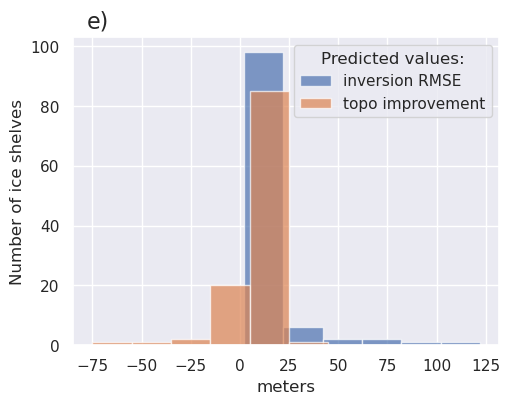

In [133]:
df = shelves_in_limits

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.hist(
    df[f"inversion_rmse_from_{predict_on}"],
    bins=range(
        round(min(df[f"inversion_rmse_from_{predict_on}"])),
        round(max(df[f"inversion_rmse_from_{predict_on}"])) + 20,
        20,
    ),
    alpha=0.7,
    label="inversion RMSE",
)
ax.hist(
    df[f"topo_improvement_rmse_from_{predict_on}"],
    bins=range(
        round(min(df[f"topo_improvement_rmse_from_{predict_on}"])),
        round(max(df[f"topo_improvement_rmse_from_{predict_on}"])) + 20,
        20,
    ),
    alpha=0.7,
    label="topo improvement",
)
fig.text(0.15, 0.95, "e)", fontsize=16, va="top", ha="left")

plt.xlabel("meters")
plt.ylabel("Number of ice shelves")
plt.legend(title="Predicted values:")

fig.savefig(
    "../paper/figures/predicted_ice_shelf_values.png",
    bbox_inches="tight",
    dpi=300,
)

In [134]:
sampled_params_df[
    [
        "constraint_numbers",
        "constraints_per_10000sq_km",
        "median_proximity",
        "regional_stdev",
    ]
]

,constraint_numbers,constraints_per_10000sq_km,median_proximity,regional_stdev
0,4,282.666667,17.755,4.089101
1,4,282.666667,17.755,8.178203
2,4,282.666667,17.755,12.267304
3,4,282.666667,17.755,16.356405
4,4,282.666667,17.755,20.445507
...,...,...,...,...
95,650,496.666667,2.520,24.534608
96,650,496.666667,2.520,28.623709
97,650,496.666667,2.520,32.712811
98,650,496.666667,2.520,36.801912


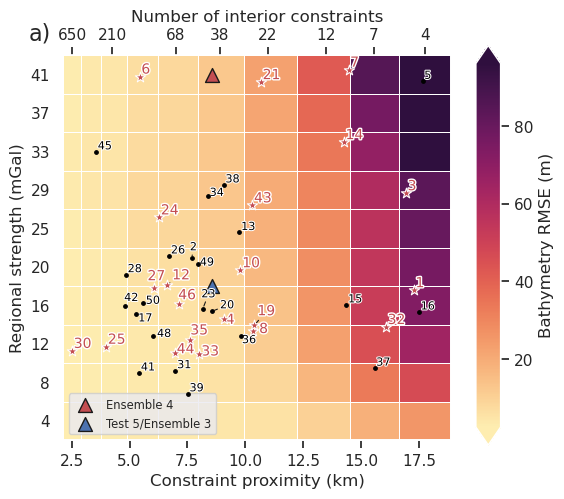

In [135]:
fig = synth_plotting.plot_2var_ensemble(
    sampled_params_df,
    figsize=(5, 5),
    x="median_proximity",
    x_title="Constraint proximity (km)",
    y="regional_stdev",
    y_title="Regional strength (mGal)",
    background="final_inversion_rmse",
    background_title="Bathymetry RMSE (m)",
    background_robust=True,
    background_cpt_lims=polar_utils.get_min_max(
        sampled_params_df.final_inversion_rmse,
        robust=True,
    ),
    constrained_layout=False,
)
ax = fig.get_axes()[0]
plt.gcf().text(0.1, 0.9, "a)", fontsize=16, va="bottom", ha="right")
ax.grid(True)

# add second x axis with number of constraints
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
x_tick_vals = sampled_params_df.median_proximity.unique()
x_tick_labels = sampled_params_df.constraint_numbers.unique()
inds_to_remove = [-2, -4]
x_tick_vals = np.delete(x_tick_vals, inds_to_remove)
x_tick_labels = np.delete(x_tick_labels, inds_to_remove)
x_tick_labels = [round(x) for x in x_tick_labels]
ax2.set_xticks(x_tick_vals)
ax2.set_xticklabels(x_tick_labels)
ax2.grid(False)
ax2.set_xlabel("Number of interior constraints")

# specify y ticks
yvals = list(sampled_params_df.regional_stdev.unique())
ax.set_yticks(yvals)
ax.set_yticklabels([round(x) for x in yvals])

df = shelves_to_plot
ice_shelf_stats.add_shelves_to_ensembles(
    x="median_constraint_distance",
    y=predict_on,
    ice_shelves=df,
    ax=ax,
    legend=False,
)
ax.scatter(
    x=8.557,  # median constraint proximity
    y=40.8,  # regional stdev
    marker="^",
    s=100,
    color="r",
    linewidth=1,
    edgecolor="k",
    label="Ensemble 4",
)
ax.scatter(
    x=8.557,  # median constraint proximity
    y=18.41093,  # regional stdev
    marker="^",
    s=100,
    color="b",
    linewidth=1,
    edgecolor="k",
    label="Test 5/Ensemble 3",
)
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[-2:],
    labels[-2:],
    fontsize="x-small",
    loc="lower left",
)

plt.minorticks_off()

fig.savefig(
    "../paper/figures/Ross_Sea_constraint_vs_regional_ensemble_bathy_error_2var.png",
    bbox_inches="tight",
    dpi=300,
)

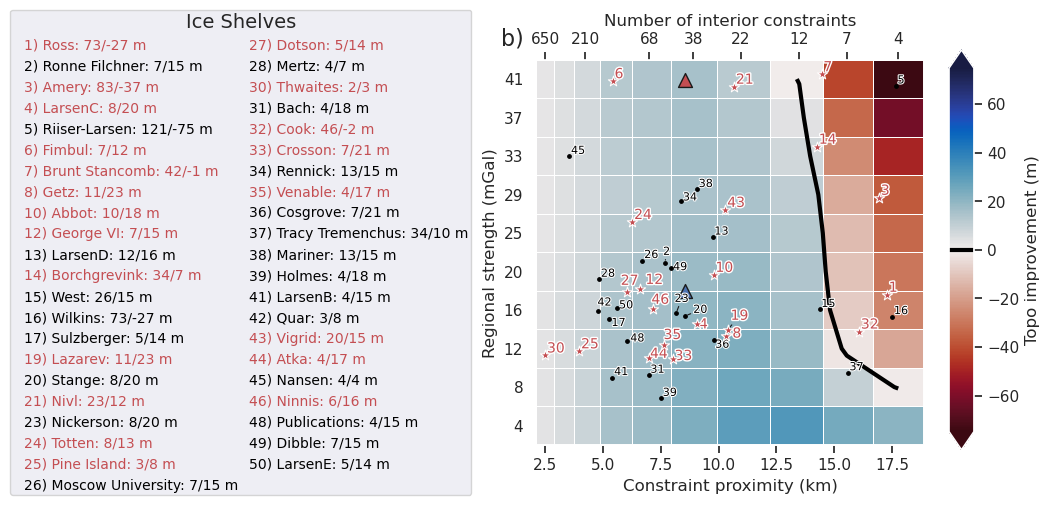

In [136]:
df = sampled_params_df
fig = synth_plotting.plot_2var_ensemble(
    df,
    figsize=(5, 5),
    x="median_proximity",
    x_title="Constraint proximity (km)",
    y="regional_stdev",
    y_title="Regional strength (mGal)",
    background="final_inversion_topo_improvement_rmse",
    background_title="Topo improvement (m)",
    background_cmap="cmo.balance_r",
    background_robust=True,
    background_cpt_lims=polar_utils.get_min_max(
        df.final_inversion_topo_improvement_rmse,
        absolute=True,
        robust_percentiles=(0.01, 0.99),
    ),
    plot_contours=[0],
    contour_color="black",
    constrained_layout=False,
)
ax = fig.get_axes()[0]
plt.gcf().text(0.1, 0.9, "b)", fontsize=16, va="bottom", ha="right")
ax.grid(True)

# add second x axis just change labels not values
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())

x_tick_vals = sampled_params_df.median_proximity.unique()
x_tick_labels = sampled_params_df.constraint_numbers.unique()

inds_to_remove = [-2, -4]
x_tick_vals = np.delete(x_tick_vals, inds_to_remove)
x_tick_labels = np.delete(x_tick_labels, inds_to_remove)

x_tick_labels = [round(x) for x in x_tick_labels]
ax2.set_xticks(x_tick_vals)
ax2.set_xticklabels(x_tick_labels)
ax2.grid(False)
ax2.set_xlabel("Number of interior constraints")

# specify y ticks
yvals = list(sampled_params_df.regional_stdev.unique())
ax.set_yticks(yvals)
ax.set_yticklabels([round(x) for x in yvals])

df = shelves_to_plot

ice_shelf_stats.add_shelves_to_ensembles(
    x="median_constraint_distance",
    y=predict_on,
    ice_shelves=df,
    shelves_to_label=df.NAME.unique(),
    ax=ax,
    legend=True,
    legend_cols=2,
    legend_loc="center right",
    legend_bbox_to_anchor=(-0.15, 0.5),
    col_to_add_to_label=[
        f"inversion_rmse_from_{predict_on}",
        f"topo_improvement_rmse_from_{predict_on}",
    ],
)

ax.scatter(
    x=8.557,  # median constraint proximity
    y=40.8,  # regional stdev
    marker="^",
    s=100,
    color="r",
    linewidth=1,
    edgecolor="k",
)
ax.scatter(
    x=8.557,  # median constraint proximity
    y=18.41093,  # regional stdev
    marker="^",
    s=100,
    color="b",
    linewidth=1,
    edgecolor="k",
)

plt.minorticks_off()

fig.savefig(
    "../paper/figures/Ross_Sea_constraint_vs_regional_ensemble_topo_improvement_2var.png",
    bbox_inches="tight",
    dpi=300,
)

Text(0.01, 0.95, 'c)')

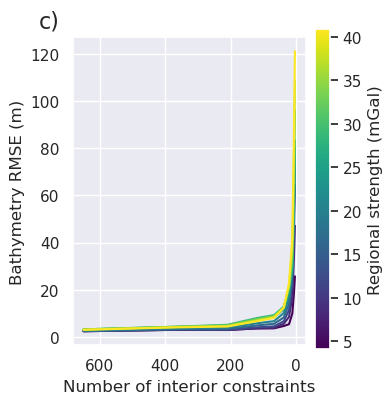

In [137]:
fig = synth_plotting.plot_ensemble_as_lines(
    sampled_params_df,
    figsize=(3, 4),
    x="constraint_numbers",
    x_label="Number of interior constraints",
    y="final_inversion_rmse",
    y_label="Bathymetry RMSE (m)",
    groupby_col="regional_stdev",
    cbar_label="Regional strength (mGal)",
    markersize=0,
    flipx=True,
)
ax = fig.get_axes()[0]
plt.gcf().text(0.01, 0.95, "c)", fontsize=16, va="top", ha="left")

In [138]:
x = "constraint_numbers"
y = "median_proximity"

df = sampled_params_df[[x, y]].copy()

df = pd.concat(
    [df, pd.DataFrame({x: np.arange(df[x].min(), df[x].max(), 1)})]
).drop_duplicates(subset=x)
df = df.sort_values(x).reset_index(drop=True)

df = synthetic.scipy_interp1d(
    df,
    to_interp=y,
    interp_on=x,
    method="cubic",
)
df[df[x].isin([30, 46, 48])]

,constraint_numbers,median_proximity
26,30,9.722335
42,46,8.261219
44,48,8.119503


In [139]:
sampled_params_df[["median_proximity", "constraint_numbers"]].drop_duplicates()

,median_proximity,constraint_numbers
0,17.755,4
10,15.534,7
20,13.483,12
30,10.966,22
40,8.902,38
50,7.011,68
60,5.491,119
70,4.256,210
80,3.279,369
90,2.520,650


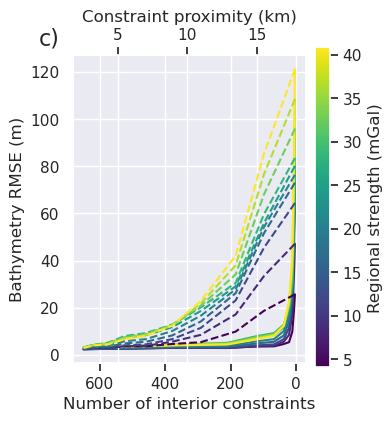

In [140]:
ax2 = ax.twiny()
groupby_col = "regional_stdev"
results = sampled_params_df
x = "median_proximity"
y = "final_inversion_rmse"

grouped = results.groupby(groupby_col)
norm = plt.Normalize(
    vmin=results[groupby_col].to_numpy().min(),
    vmax=results[groupby_col].to_numpy().max(),
)
slopes = []
lines = []
for _i, (name, group) in enumerate(grouped):
    ax2.plot(
        group[x],
        group[y],
        "--",
        markersize=0,
        color=plt.cm.viridis(norm(name)),
    )
ax2.set_xlabel("Constraint proximity (km)")

fig.savefig(
    "../paper/figures/Ross_Sea_constraint_vs_regional_ensemble_bathy_error_vs_median_proximity.png",
    bbox_inches="tight",
    dpi=300,
)
fig

Text(0.01, 0.95, 'e)')

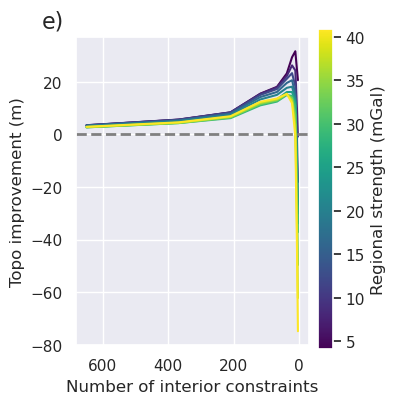

In [141]:
fig = synth_plotting.plot_ensemble_as_lines(
    sampled_params_df,
    figsize=(3, 4),
    x="constraint_numbers",
    x_label="Number of interior constraints",
    y="final_inversion_topo_improvement_rmse",
    y_label="Topo improvement (m)",
    groupby_col="regional_stdev",
    cbar_label="Regional strength (mGal)",
    horizontal_line=0,
    markersize=0,
    flipx=True,
)
ax = fig.get_axes()[0]
plt.gcf().text(0.01, 0.95, "e)", fontsize=16, va="top", ha="left")

In [142]:
grouped = sampled_params_df.groupby("regional_stdev")
x = "constraint_numbers"
y = "final_inversion_topo_improvement_rmse"

constraint_numbers_at_max = []
for _i, (_name, group) in enumerate(grouped):
    df = group[[x, y]].copy()

    df = pd.concat(
        [df, pd.DataFrame({x: np.arange(df[x].min(), df[x].max(), 1)})]
    ).drop_duplicates(subset=x)
    df = df.sort_values(x).reset_index(drop=True)

    df = synthetic.scipy_interp1d(
        df,
        to_interp=y,
        interp_on=x,
        method="cubic",
    )
    max_ind = df[y].idxmax()
    constraint_numbers_at_max.append(df[x].iloc[max_ind])
constraint_numbers_at_max

[np.int64(15),
 np.int64(17),
 np.int64(18),
 np.int64(17),
 np.int64(17),
 np.int64(17),
 np.int64(17),
 np.int64(17),
 np.int64(47),
 np.int64(48)]

In [143]:
grouped = sampled_params_df.groupby("regional_stdev")
x = "median_proximity"
y = "final_inversion_topo_improvement_rmse"

median_proximity_at_max = []
for _i, (_name, group) in enumerate(grouped):
    df = group[[x, y]].copy()

    df = pd.concat(
        [df, pd.DataFrame({x: np.arange(df[x].min(), df[x].max(), 1)})]
    ).drop_duplicates(subset=x)
    df = df.sort_values(x).reset_index(drop=True)

    df = synthetic.scipy_interp1d(
        df,
        to_interp=y,
        interp_on=x,
        method="cubic",
    )
    max_ind = df[y].idxmax()
    median_proximity_at_max.append(df[x].iloc[max_ind])
median_proximity_at_max

[np.float64(12.52),
 np.float64(12.52),
 np.float64(11.52),
 np.float64(11.52),
 np.float64(11.52),
 np.float64(11.52),
 np.float64(12.52),
 np.float64(8.902),
 np.float64(8.902),
 np.float64(8.902)]

In [144]:
df = sampled_params_df[["median_proximity", "constraint_numbers"]].drop_duplicates()
df = pd.concat(
    [
        df,
        pd.DataFrame(
            {
                "constraint_numbers": np.arange(
                    df.constraint_numbers.min(), df.constraint_numbers.max(), 1
                )
            }
        ),
    ]
).drop_duplicates(subset="constraint_numbers")
df = df.sort_values("constraint_numbers").reset_index(drop=True)

df = synthetic.scipy_interp1d(
    df,
    to_interp="median_proximity",
    interp_on="constraint_numbers",
    method="cubic",
)
df[df.constraint_numbers.isin(constraint_numbers_at_max)]

,median_proximity,constraint_numbers
11,12.603298,15
13,12.077271,17
14,11.831991,18
43,8.189504,47
44,8.119503,48


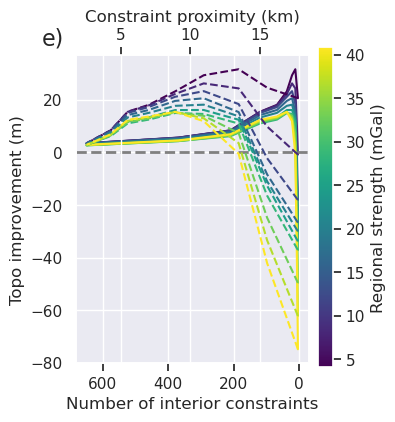

In [145]:
ax2 = ax.twiny()
groupby_col = "regional_stdev"
results = sampled_params_df
x = "median_proximity"
y = "final_inversion_topo_improvement_rmse"

grouped = results.groupby(groupby_col)

norm = plt.Normalize(
    vmin=results[groupby_col].to_numpy().min(),
    vmax=results[groupby_col].to_numpy().max(),
)
slopes = []
lines = []
for _i, (name, group) in enumerate(grouped):
    ax2.plot(
        group[x],
        group[y],
        "--",
        markersize=0,
        color=plt.cm.viridis(norm(name)),
    )

ax2.set_xlabel("Constraint proximity (km)")
fig

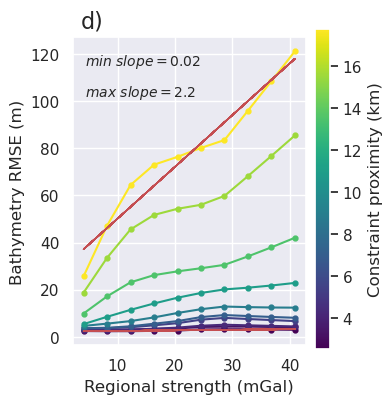

In [146]:
fig = synth_plotting.plot_ensemble_as_lines(
    sampled_params_df,
    figsize=(3, 4),
    x="regional_stdev",
    x_label="Regional strength (mGal)",
    y="final_inversion_rmse",
    y_label="Bathymetry RMSE (m)",
    groupby_col="median_proximity",
    cbar_label="Constraint proximity (km)",
    trend_line=True,
    slope_min_max=True,
    slope_decimals=2,
)

plt.gcf().text(0.15, 0.95, "d)", fontsize=16, va="top", ha="left")

plt.savefig(
    "../paper/figures/Ross_Sea_constraint_vs_regional_ensemble_bathy_error_vs_regional_strength.png",
    bbox_inches="tight",
    dpi=300,
)

Text(0.15, 0.95, 'f)')

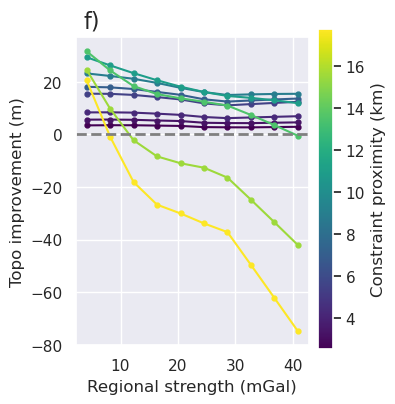

In [147]:
fig = synth_plotting.plot_ensemble_as_lines(
    sampled_params_df,
    figsize=(3, 4),
    x="regional_stdev",
    x_label="Regional strength (mGal)",
    y="final_inversion_topo_improvement_rmse",
    y_label="Topo improvement (m)",
    groupby_col="median_proximity",
    cbar_label="Constraint proximity (km)",
    horizontal_line=0,
)
plt.gcf().text(0.15, 0.95, "f)", fontsize=16, va="top", ha="left")

## Ensembles 2-4: grav spacing vs noise

In [4]:
no_ensemble_path = "../results/Ross_Sea/ensembles/Ross_Sea_ensemble_02_grav_spacing_vs_noise_no_regional_density_estimation"
no_ensemble_fname = f"{no_ensemble_path}.csv"
sampled_params_df_no_regional = pd.read_csv(no_ensemble_fname)

medium_ensemble_path = "../results/Ross_Sea/ensembles/Ross_Sea_ensemble_03_grav_spacing_vs_noise_medium_regional_density_estimation"
medium_ensemble_fname = f"{medium_ensemble_path}.csv"
sampled_params_df_medium_regional = pd.read_csv(medium_ensemble_fname)

strong_ensemble_path = "../results/Ross_Sea/ensembles/Ross_Sea_ensemble_04_grav_spacing_vs_noise_strong_regional_density_estimation"
strong_ensemble_fname = f"{strong_ensemble_path}.csv"
sampled_params_df_strong_regional = pd.read_csv(strong_ensemble_fname)

In [5]:
bathymetry_path = pathlib.Path(no_ensemble_path + "_starting_bathymetry").with_suffix(
    ".nc"
)
starting_bathymetry = xr.open_dataarray(bathymetry_path)

starting_bathymetry = starting_bathymetry.sel(
    easting=slice(plot_region[0], plot_region[1]),
    northing=slice(plot_region[2], plot_region[3]),
)

constraints_path = pathlib.Path(no_ensemble_path + "_constraint_points").with_suffix(
    ".csv"
)
constraint_points = pd.read_csv(constraints_path)

starting_bathymetry_rmse = float(utils.rmse(bathymetry - starting_bathymetry))

contours = [starting_bathymetry_rmse]

starting_bathymetry_rmse

25.977349421327325

In [6]:
figsize = (4, 4)

cpt_lims = polar_utils.get_combined_min_max(
    [
        sampled_params_df_no_regional.final_inversion_rmse,
        sampled_params_df_medium_regional.final_inversion_rmse,
        sampled_params_df_strong_regional.final_inversion_rmse,
    ],
    robust=True,
    robust_percentiles=(0.1, 0.9),
)
line_plot_ylims = polar_utils.get_combined_min_max(
    [
        sampled_params_df_no_regional.final_inversion_rmse,
        sampled_params_df_medium_regional.final_inversion_rmse,
        sampled_params_df_strong_regional.final_inversion_rmse,
    ],
)
line_plot_ylims = (line_plot_ylims[0] * 0.9, line_plot_ylims[1] * 1.1)

cpt_lims

(np.float64(11.536359095996527), np.float64(37.96154893557483))

### Plot optimal filter widths

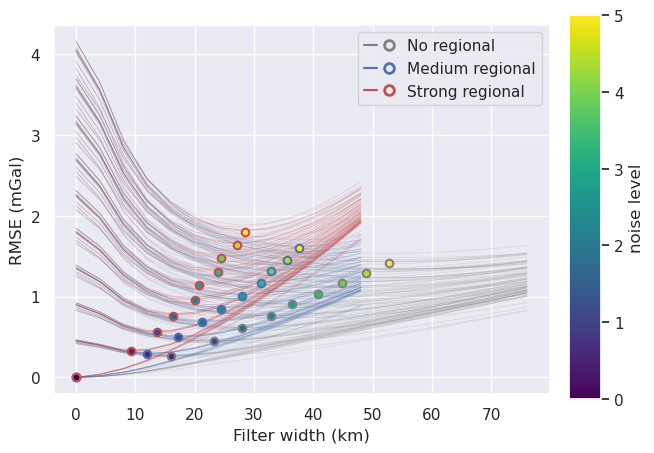

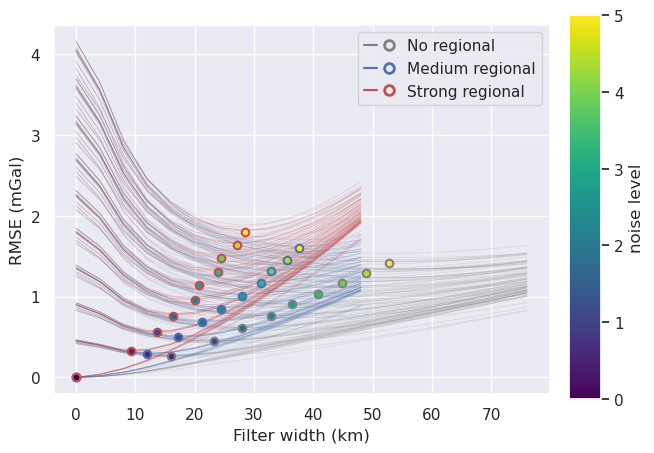

In [151]:
fig, ax = plt.subplots()

norm = plt.Normalize(
    vmin=sampled_params_df_no_regional.grav_noise_levels.to_numpy().min(),
    vmax=sampled_params_df_no_regional.grav_noise_levels.to_numpy().max(),
)

grouped = sampled_params_df_no_regional.groupby("grav_noise_levels")
for name, group in grouped:
    best_filters = []
    best_rmses = []
    for _i, row in group.iterrows():
        # load data
        filter_width_trials = pd.read_csv(row.filter_width_trials_fname)

        best_ind = filter_width_trials.rmse.idxmin()
        best_filter_width = filter_width_trials.iloc[best_ind].filt_width
        best_rmse = filter_width_trials.iloc[best_ind].rmse
        best_filters.append(best_filter_width)
        best_rmses.append(best_rmse)

        ax.plot(
            filter_width_trials.filt_width / 1e3,
            filter_width_trials.rmse,
            color="gray",
            alpha=0.2,
            linewidth=0.5,
        )

    color = plt.cm.viridis(norm(name))  # pylint: disable=no-member
    ax.scatter(
        x=np.mean(best_filters) / 1e3,
        y=np.mean(best_rmses),
        marker="o",
        edgecolor="gray",
        linewidth=1.5,
        color=color,
        s=30,
        zorder=20,
    )

grouped = sampled_params_df_medium_regional.groupby("grav_noise_levels")
for name, group in grouped:
    best_filters = []
    best_rmses = []
    for _i, row in group.iterrows():
        # load data
        filter_width_trials = pd.read_csv(row.filter_width_trials_fname)

        best_ind = filter_width_trials.rmse.idxmin()
        best_filter_width = filter_width_trials.iloc[best_ind].filt_width
        best_rmse = filter_width_trials.iloc[best_ind].rmse
        best_filters.append(best_filter_width)
        best_rmses.append(best_rmse)

        ax.plot(
            filter_width_trials.filt_width / 1e3,
            filter_width_trials.rmse,
            color="b",
            alpha=0.2,
            linewidth=0.5,
        )

    color = plt.cm.viridis(norm(name))  # pylint: disable=no-member
    ax.scatter(
        x=np.mean(best_filters) / 1e3,
        y=np.mean(best_rmses),
        marker="o",
        edgecolor="b",
        linewidth=1.5,
        color=color,
        s=30,
        zorder=20,
    )

grouped = sampled_params_df_strong_regional.groupby("grav_noise_levels")
for name, group in grouped:
    best_filters = []
    best_rmses = []
    for _i, row in group.iterrows():
        # load data
        filter_width_trials = pd.read_csv(row.filter_width_trials_fname)

        best_ind = filter_width_trials.rmse.idxmin()
        best_filter_width = filter_width_trials.iloc[best_ind].filt_width
        best_rmse = filter_width_trials.iloc[best_ind].rmse
        best_filters.append(best_filter_width)
        best_rmses.append(best_rmse)

        ax.plot(
            filter_width_trials.filt_width / 1e3,
            filter_width_trials.rmse,
            color="r",
            alpha=0.2,
            linewidth=0.5,
        )

    color = plt.cm.viridis(norm(name))  # pylint: disable=no-member
    ax.scatter(
        x=np.mean(best_filters) / 1e3,
        y=np.mean(best_rmses),
        marker="o",
        edgecolor="r",
        linewidth=1.5,
        color=color,
        s=30,
        zorder=20,
    )

ax.set_xlabel("Filter width (km)")
ax.set_ylabel("RMSE (mGal)")
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
cax = fig.add_axes([0.93, 0.1, 0.05, 0.8])
cbar = plt.colorbar(sm, cax=cax)
cbar.set_label("noise level")

# create manual symbols for legend
symbols = []
line = mpl.lines.Line2D(
    [0],
    [0],
    color="gray",
)
point = mpl.lines.Line2D(
    [0],
    [0],
    marker="o",
    markersize=7,
    markeredgecolor="gray",
    markerfacecolor="None",
    markeredgewidth=2,
    linestyle="",
)
symbols.append((line, point))

line = mpl.lines.Line2D(
    [0],
    [0],
    color="b",
)
point = mpl.lines.Line2D(
    [0],
    [0],
    marker="o",
    markersize=7,
    markeredgecolor="b",
    markerfacecolor="None",
    markeredgewidth=2,
    linestyle="",
)
symbols.append((line, point))

line = mpl.lines.Line2D(
    [0],
    [0],
    color="r",
)
point = mpl.lines.Line2D(
    [0],
    [0],
    marker="o",
    markersize=7,
    markeredgecolor="r",
    markerfacecolor="None",
    markeredgewidth=2,
    linestyle="",
)
symbols.append((line, point))

ax.legend(
    symbols,
    ["No regional", "Medium regional", "Strong regional"],
    handler_map={tuple: mpl.legend_handler.HandlerTuple(ndivide=None)},
)


fig

Text(0, 0.5, 'Gravity noise level (mGal)')

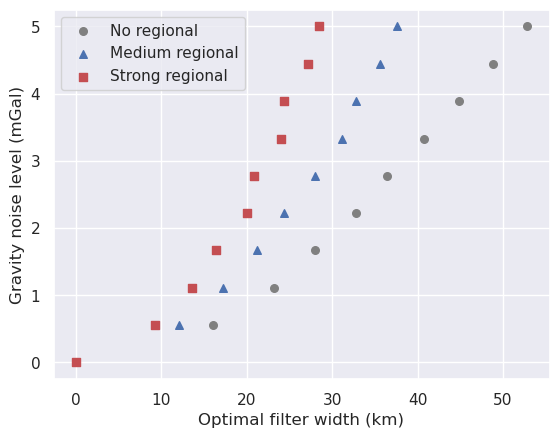

In [152]:
fig, ax = plt.subplots()

grouped = sampled_params_df_no_regional.groupby("grav_noise_levels")
for j, (name, group) in enumerate(grouped):
    best_filters = []
    for i, row in group.iterrows():
        filter_width_trials = pd.read_csv(row.filter_width_trials_fname)
        best_ind = filter_width_trials.rmse.idxmin()
        best_filter_width = filter_width_trials.iloc[best_ind].filt_width
        best_filters.append(best_filter_width)

    color = "gray"
    label = "No regional" if j == 0 else None
    ax.scatter(
        x=np.mean(best_filters) / 1e3,
        y=name,
        marker="o",
        color=color,
        s=30,
        zorder=20,
        label=label,
    )

grouped = sampled_params_df_medium_regional.groupby("grav_noise_levels")
for j, (name, group) in enumerate(grouped):
    best_filters = []
    for _i, row in group.iterrows():
        filter_width_trials = pd.read_csv(row.filter_width_trials_fname)
        best_ind = filter_width_trials.rmse.idxmin()
        best_filter_width = filter_width_trials.iloc[best_ind].filt_width
        best_filters.append(best_filter_width)

    color = "b"
    label = "Medium regional" if j == 0 else None
    ax.scatter(
        x=np.mean(best_filters) / 1e3,
        y=name,
        marker="^",
        color=color,
        s=30,
        zorder=20,
        label=label,
    )


grouped = sampled_params_df_strong_regional.groupby("grav_noise_levels")
for j, (name, group) in enumerate(grouped):
    best_filters = []
    for _i, row in group.iterrows():
        filter_width_trials = pd.read_csv(row.filter_width_trials_fname)
        best_ind = filter_width_trials.rmse.idxmin()
        best_filter_width = filter_width_trials.iloc[best_ind].filt_width
        best_filters.append(best_filter_width)

    color = "r"
    label = "Strong regional" if j == 0 else None
    ax.scatter(
        x=np.mean(best_filters) / 1e3,
        y=name,
        marker="s",
        color=color,
        s=30,
        zorder=20,
        label=label,
    )

ax.legend()
ax.set_xlabel("Optimal filter width (km)")
ax.set_ylabel("Gravity noise level (mGal)")

Text(0.5, 1.0, 'Optimal filter width')

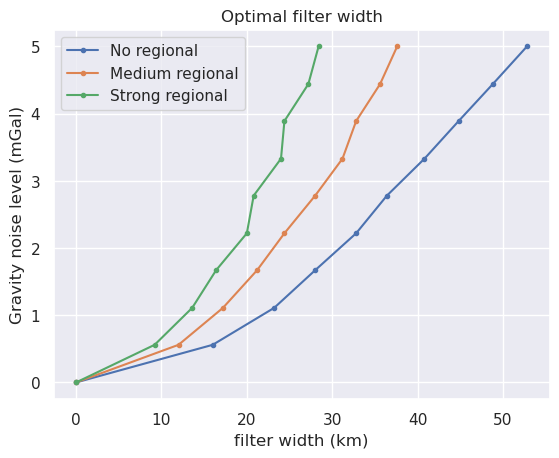

In [153]:
fig, ax = plt.subplots()

dfs = []
grouped = sampled_params_df_no_regional.groupby("grav_noise_levels")
for _j, (name, group) in enumerate(grouped):
    best_filters = []
    for _i, row in group.iterrows():
        filter_width_trials = pd.read_csv(row.filter_width_trials_fname)
        best_ind = filter_width_trials.rmse.idxmin()
        best_filter_width = filter_width_trials.iloc[best_ind].filt_width
        best_filters.append(best_filter_width)

    dfs.append(
        pd.DataFrame(
            [
                {
                    "filter_width": np.mean(best_filters) / 1e3,
                    "noise": name,
                    "regional": "none",
                }
            ]
        )
    )

grouped = sampled_params_df_medium_regional.groupby("grav_noise_levels")
for _j, (name, group) in enumerate(grouped):
    best_filters = []
    for _i, row in group.iterrows():
        filter_width_trials = pd.read_csv(row.filter_width_trials_fname)
        best_ind = filter_width_trials.rmse.idxmin()
        best_filter_width = filter_width_trials.iloc[best_ind].filt_width
        best_filters.append(best_filter_width)

    dfs.append(
        pd.DataFrame(
            [
                {
                    "filter_width": np.mean(best_filters) / 1e3,
                    "noise": name,
                    "regional": "medium",
                }
            ]
        )
    )

grouped = sampled_params_df_strong_regional.groupby("grav_noise_levels")
for _j, (name, group) in enumerate(grouped):
    best_filters = []
    for _i, row in group.iterrows():
        filter_width_trials = pd.read_csv(row.filter_width_trials_fname)
        best_ind = filter_width_trials.rmse.idxmin()
        best_filter_width = filter_width_trials.iloc[best_ind].filt_width
        best_filters.append(best_filter_width)

    dfs.append(
        pd.DataFrame(
            [
                {
                    "filter_width": np.mean(best_filters) / 1e3,
                    "noise": name,
                    "regional": "strong",
                }
            ]
        )
    )

df = pd.concat(dfs)

df_subset = df[df.regional == "none"]
ax.plot(
    df_subset.filter_width,
    df_subset.noise,
    ".-",
    label="No regional",
)
df_subset = df[df.regional == "medium"]
ax.plot(
    df_subset.filter_width,
    df_subset.noise,
    ".-",
    label="Medium regional",
)
df_subset = df[df.regional == "strong"]
ax.plot(
    df_subset.filter_width,
    df_subset.noise,
    ".-",
    label="Strong regional",
)

ax.legend()
ax.set_xlabel("filter width (km)")
ax.set_ylabel("Gravity noise level (mGal)")
ax.set_title("Optimal filter width")

### No regional

In [7]:
sampled_params_df_no_regional[
    [
        "final_inversion_rmse",
        "final_inversion_topo_improvement_rmse",
    ]
].describe()

,final_inversion_rmse,final_inversion_topo_improvement_rmse
count,100.000000,100.000000
mean,24.420991,1.556358
std,10.067175,10.067175
min,3.387418,-23.450514
25%,17.763109,-3.645639
50%,24.550003,1.427347
75%,29.622989,8.214240
max,49.427864,22.589931


In [8]:
sampled_params_df_no_regional.columns

Index(['grav_line_numbers', 'grav_noise_levels', 'grav_df_fname',
       'grav_survey_df_fname', 'grav_line_spacing', 'grav_proximity',
       'grav_proximity_skew', 'flight_kms', 'flight_kms_per_10000sq_km',
       'filter_width_trials_fname', 'best_filter_width', 'grav_data_loss_rmse',
       'grav_data_loss_mae', 'results_fname', 'inverted_bathymetry_fname',
       'best_density_contrast', 'constraints_rmse', 'inversion_rmse',
       'final_inversion_fname', 'final_inverted_bathymetry_fname',
       'final_inversion_constraints_rmse', 'final_inversion_rmse',
       'final_inversion_topo_improvement_rmse'],
      dtype='object')

In [9]:
np.linspace(5, 55, 6)

array([ 5., 15., 25., 35., 45., 55.])

In [10]:
df = sampled_params_df_no_regional[
    ["grav_proximity", "grav_line_spacing"]
].drop_duplicates()
df = df.sort_values("grav_line_spacing", ascending=False)
df = pd.concat(
    [
        df,
        pd.DataFrame(
            {
                "grav_line_spacing": np.arange(
                    round(df.grav_line_spacing.min()),
                    round(df.grav_line_spacing.max()) + 1,
                    1,
                )
            }
        ),
    ]
).drop_duplicates(subset="grav_line_spacing")
df = df.sort_values("grav_line_spacing", ascending=False).reset_index(drop=True)

df = synthetic.scipy_interp1d(
    df,
    to_interp="grav_proximity",
    interp_on="grav_line_spacing",
    method="cubic",
)
df = df[["grav_line_spacing", "grav_proximity"]]

df = df[
    df.grav_line_spacing.isin(
        np.arange(
            round(sampled_params_df_no_regional.grav_line_spacing.min()),
            round(sampled_params_df_no_regional.grav_line_spacing.max()) + 1,
            10,
        )
    )
]
df

,grav_line_spacing,grav_proximity
3,56.0,8.016317
13,46.0,6.580356
24,36.0,5.139188
35,26.0,3.736880
46,16.0,2.294572
60,6.0,0.851066


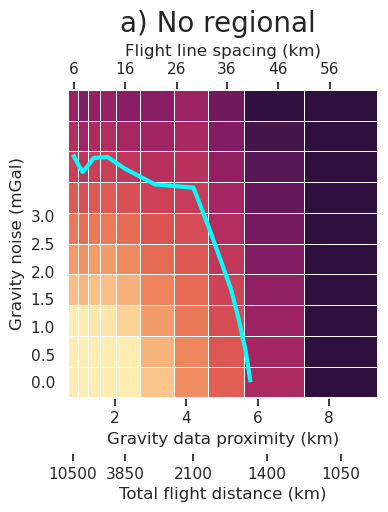

In [11]:
fig = synth_plotting.plot_2var_ensemble(
    sampled_params_df_no_regional,
    figsize=figsize,
    x="grav_proximity",
    x_title="Gravity data proximity (km)",
    y="grav_noise_levels",
    y_title="Gravity noise (mGal)",
    background="final_inversion_rmse",
    background_title="Bathymetry RMSE (m)",
    background_robust=True,
    plot_contours=contours,
    contour_color="cyan",
    background_cpt_lims=cpt_lims,
    colorbar=False,
    constrained_layout=False,
)
plt.gcf().text(0.5, 1.01, "a) No regional", fontsize=20, va="bottom", ha="center")
ax = fig.get_axes()[0]

# add second x axis with flight line spacing
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
x_tick_vals = df.grav_proximity.unique()
x_tick_labels = df.grav_line_spacing.unique()
x_tick_labels = [int(x) for x in x_tick_labels]
ax2.set_xticks(x_tick_vals)
ax2.set_xticklabels(x_tick_labels)
ax2.grid(False)
ax2.set_xlabel("Flight line spacing (km)")

# add third x axis for flight distance
ax3 = ax.twiny()
ax3.set_xlim(ax.get_xlim())
x_tick_vals = sampled_params_df_no_regional.grav_proximity.unique()
x_tick_labels = sampled_params_df_no_regional.flight_kms.unique()
inds_to_remove = [-2, -3, -4, -6, -8]
x_tick_vals = np.delete(x_tick_vals, inds_to_remove)
x_tick_labels = np.delete(x_tick_labels, inds_to_remove)
x_tick_labels = [round(x) for x in x_tick_labels]
ax3.set_xticks(x_tick_vals)
ax3.set_xticklabels(x_tick_labels)
ax3.grid(False)
ax3.set_xlabel("Total flight distance (km)")
ax3.xaxis.set_ticks_position("bottom")
ax3.xaxis.set_label_position("bottom")
ax3.spines["bottom"].set_position(("outward", 40))

# specify y ticks
ax.set_yticks(np.arange(0, 3.5, 0.5))

fig.savefig(
    "../paper/figures/Ross_Sea_noise_vs_spacing_no_regional_2var.png",
    bbox_inches="tight",
    dpi=300,
)

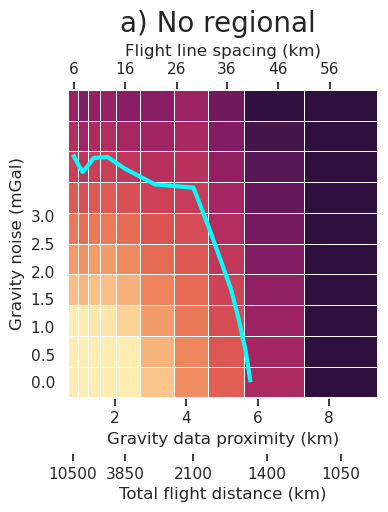

In [12]:
fig = synth_plotting.plot_2var_ensemble(
    sampled_params_df_no_regional,
    figsize=figsize,
    x="grav_proximity",
    x_title="Gravity data proximity (km)",
    y="grav_noise_levels",
    y_title="Gravity noise (mGal)",
    background="final_inversion_rmse",
    background_title="Bathymetry RMSE (m)",
    background_robust=True,
    plot_contours=contours,
    contour_color="cyan",
    background_cpt_lims=cpt_lims,
    colorbar=False,
    constrained_layout=False,
)
plt.gcf().text(0.5, 1.01, "a) No regional", fontsize=20, va="bottom", ha="center")
ax = fig.get_axes()[0]

# add second x axis with flight line spacing
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
x_tick_vals = df.grav_proximity.unique()
x_tick_labels = df.grav_line_spacing.unique()
x_tick_labels = [int(x) for x in x_tick_labels]
ax2.set_xticks(x_tick_vals)
ax2.set_xticklabels(x_tick_labels)
ax2.grid(False)
ax2.set_xlabel("Flight line spacing (km)")

# add third x axis for flight distance
ax3 = ax.twiny()
ax3.set_xlim(ax.get_xlim())
x_tick_vals = sampled_params_df_no_regional.grav_proximity.unique()
x_tick_labels = sampled_params_df_no_regional.flight_kms.unique()
inds_to_remove = [-2, -3, -4, -6, -8]
x_tick_vals = np.delete(x_tick_vals, inds_to_remove)
x_tick_labels = np.delete(x_tick_labels, inds_to_remove)
x_tick_labels = [round(x) for x in x_tick_labels]
ax3.set_xticks(x_tick_vals)
ax3.set_xticklabels(x_tick_labels)
ax3.grid(False)
ax3.set_xlabel("Total flight distance (km)")
ax3.xaxis.set_ticks_position("bottom")
ax3.xaxis.set_label_position("bottom")
ax3.spines["bottom"].set_position(("outward", 40))

# specify y ticks
ax.set_yticks(np.arange(0, 3.5, 0.5))

fig.savefig(
    "../paper/figures/Ross_Sea_noise_vs_spacing_no_regional_2var_supplement.png",
    bbox_inches="tight",
    dpi=300,
)

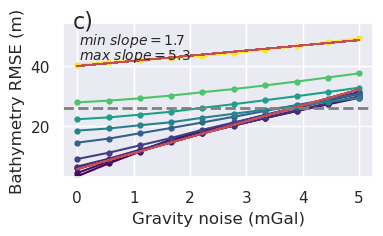

In [13]:
fig = synth_plotting.plot_ensemble_as_lines(
    sampled_params_df_no_regional,
    figsize=(figsize[0], figsize[1] / 2),
    x="grav_noise_levels",
    x_label="Gravity noise (mGal)",
    y="final_inversion_rmse",
    y_label="Bathymetry RMSE (m)",
    groupby_col="grav_line_spacing",
    cbar_label="Line spacing (km)",
    trend_line=True,
    slope_min_max=True,
    slope_decimals=1,
    horizontal_line=contours,
    y_lims=line_plot_ylims,
    colorbar=False,
)
plt.gcf().text(0.15, 0.95, "c)", fontsize=16, va="top", ha="left")

plt.savefig(
    "../paper/figures/Ross_Sea_noise_vs_spacing_no_regional_bathy_error_vs_grav_noise.png",
    bbox_inches="tight",
    dpi=300,
)

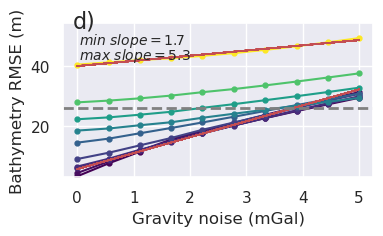

In [14]:
fig = synth_plotting.plot_ensemble_as_lines(
    sampled_params_df_no_regional,
    figsize=(figsize[0], figsize[1] / 2),
    x="grav_noise_levels",
    x_label="Gravity noise (mGal)",
    y="final_inversion_rmse",
    y_label="Bathymetry RMSE (m)",
    groupby_col="grav_line_spacing",
    cbar_label="Line spacing (km)",
    trend_line=True,
    slope_min_max=True,
    slope_decimals=1,
    horizontal_line=contours,
    y_lims=line_plot_ylims,
    colorbar=False,
)
plt.gcf().text(0.15, 0.95, "d)", fontsize=16, va="top", ha="left")

plt.savefig(
    "../paper/figures/Ross_Sea_noise_vs_spacing_no_regional_bathy_error_vs_grav_noise_supplement.png",
    bbox_inches="tight",
    dpi=300,
)

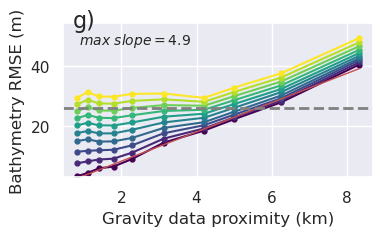

In [15]:
x = "grav_proximity"
fig = synth_plotting.plot_ensemble_as_lines(
    sampled_params_df_no_regional,
    figsize=(figsize[0], figsize[1] / 2),
    x=x,
    x_label="Gravity data proximity (km)",
    y="final_inversion_rmse",
    y_label="Bathymetry RMSE (m)",
    groupby_col="grav_noise_levels",
    cbar_label="Gravity noise (mGal)",
    horizontal_line=contours,
    y_lims=line_plot_ylims,
    colorbar=False,
    trend_line=True,
    slope_max=True,
    slope_decimals=1,
)
plt.gcf().text(0.15, 0.95, "g)", fontsize=16, va="top", ha="left")

plt.savefig(
    "../paper/figures/Ross_Sea_noise_vs_spacing_no_regional_bathy_error_vs_grav_spacing_2.png",
    bbox_inches="tight",
    dpi=300,
)

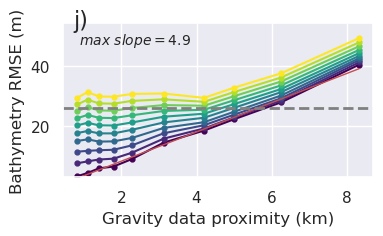

In [16]:
x = "grav_proximity"
fig = synth_plotting.plot_ensemble_as_lines(
    sampled_params_df_no_regional,
    figsize=(figsize[0], figsize[1] / 2),
    x=x,
    x_label="Gravity data proximity (km)",
    y="final_inversion_rmse",
    y_label="Bathymetry RMSE (m)",
    groupby_col="grav_noise_levels",
    cbar_label="Gravity noise (mGal)",
    horizontal_line=contours,
    y_lims=line_plot_ylims,
    colorbar=False,
    trend_line=True,
    slope_max=True,
    slope_decimals=1,
)
plt.gcf().text(0.15, 0.95, "j)", fontsize=16, va="top", ha="left")

plt.savefig(
    "../paper/figures/Ross_Sea_noise_vs_spacing_no_regional_bathy_error_vs_grav_spacing_2_supplement.png",
    bbox_inches="tight",
    dpi=300,
)

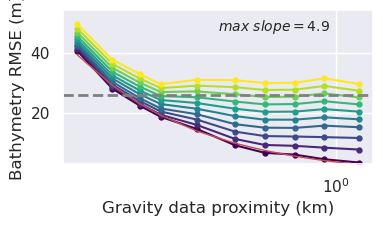

In [17]:
x = "grav_proximity"
fig = synth_plotting.plot_ensemble_as_lines(
    sampled_params_df_no_regional,
    figsize=(figsize[0], figsize[1] / 2),
    x=x,
    x_label="Gravity data proximity (km)",
    y="final_inversion_rmse",
    y_label="Bathymetry RMSE (m)",
    groupby_col="grav_noise_levels",
    cbar_label="Gravity noise (mGal)",
    horizontal_line=contours,
    y_lims=line_plot_ylims,
    logx=True,
    flipx=True,
    colorbar=False,
    trend_line=True,
    slope_max=True,
    trend_line_text_loc=(0.5, 0.95),
    slope_decimals=1,
)

In [162]:
sampled_params_df_no_regional[
    ["grav_proximity", "grav_line_spacing", "flight_kms"]
].drop_duplicates()

,grav_proximity,grav_line_spacing,flight_kms
0,8.333333,58.333333,1050.0
10,6.250800,43.750000,1400.0
20,5.001000,35.000000,1750.0
30,4.200000,29.166667,2100.0
40,3.126600,21.875000,2800.0
50,2.281510,15.909091,3850.0
60,1.788512,12.500000,4900.0
70,1.400000,9.722222,6300.0
80,1.096652,7.608696,8050.0
90,0.824621,5.833333,10500.0


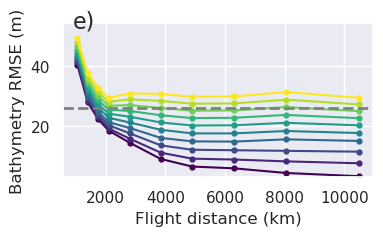

In [18]:
fig = synth_plotting.plot_ensemble_as_lines(
    sampled_params_df_no_regional,
    figsize=(figsize[0], figsize[1] / 2),
    x="flight_kms",
    x_label="Flight distance (km)",
    y="final_inversion_rmse",
    y_label="Bathymetry RMSE (m)",
    groupby_col="grav_noise_levels",
    cbar_label="Gravity noise (mGal)",
    horizontal_line=contours,
    y_lims=line_plot_ylims,
    colorbar=False,
)
plt.gcf().text(0.15, 0.95, "e)", fontsize=16, va="top", ha="left")

ax = fig.get_axes()[0]

plt.savefig(
    "../paper/figures/Ross_Sea_noise_vs_spacing_no_regional_bathy_error_vs_grav_spacing.png",
    bbox_inches="tight",
    dpi=300,
)

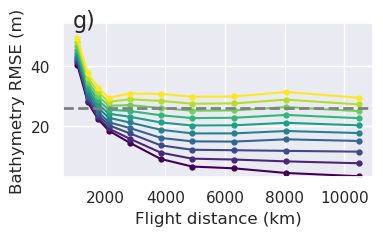

In [19]:
fig = synth_plotting.plot_ensemble_as_lines(
    sampled_params_df_no_regional,
    figsize=(figsize[0], figsize[1] / 2),
    x="flight_kms",
    x_label="Flight distance (km)",
    y="final_inversion_rmse",
    y_label="Bathymetry RMSE (m)",
    groupby_col="grav_noise_levels",
    cbar_label="Gravity noise (mGal)",
    horizontal_line=contours,
    y_lims=line_plot_ylims,
    colorbar=False,
)
plt.gcf().text(0.15, 0.95, "g)", fontsize=16, va="top", ha="left")

ax = fig.get_axes()[0]

plt.savefig(
    "../paper/figures/Ross_Sea_noise_vs_spacing_no_regional_bathy_error_vs_grav_spacing_supplement.png",
    bbox_inches="tight",
    dpi=300,
)

### Medium regional

In [20]:
sampled_params_df_medium_regional[
    [
        "final_inversion_rmse",
        "final_inversion_topo_improvement_rmse",
    ]
].describe()

,final_inversion_rmse,final_inversion_topo_improvement_rmse
count,100.000000,100.000000
mean,21.131537,4.845812
std,5.237103,5.237103
min,8.893398,-4.575229
25%,17.833364,1.527872
50%,21.596023,4.381327
75%,24.449477,8.143986
max,30.552578,17.083951


In [21]:
cols = [
    "grav_proximity",
    "grav_line_spacing",
    "grav_line_numbers",
    "flight_kms_per_10000sq_km",
]
sampled_params_df_medium_regional[cols]

,grav_proximity,grav_line_spacing,grav_line_numbers,flight_kms_per_10000sq_km
0,8.333333,58.333333,3,350.0
1,8.333333,58.333333,3,350.0
2,8.333333,58.333333,3,350.0
3,8.333333,58.333333,3,350.0
4,8.333333,58.333333,3,350.0
...,...,...,...,...
95,0.824621,5.833333,30,3500.0
96,0.824621,5.833333,30,3500.0
97,0.824621,5.833333,30,3500.0
98,0.824621,5.833333,30,3500.0


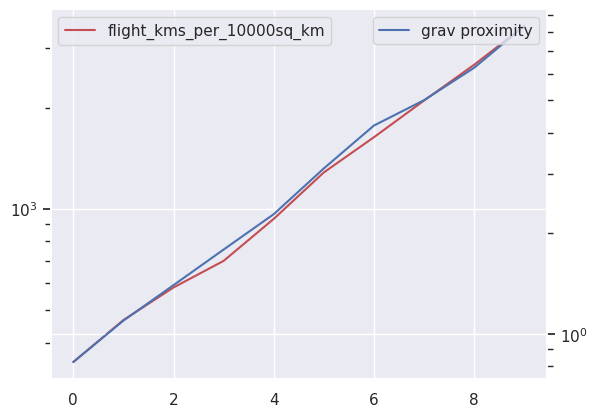

In [166]:
fig, ax = plt.subplots()

ax.plot(
    sampled_params_df_medium_regional.flight_kms_per_10000sq_km.drop_duplicates().reset_index(
        drop=True,
    ),
    c="r",
    label="flight_kms_per_10000sq_km",
)

ax2 = ax.twinx()

ax2.plot(
    sampled_params_df_medium_regional.grav_proximity.drop_duplicates()[
        ::-1
    ].reset_index(
        drop=True,
    ),
    label="grav proximity",
)
ax2.set_yscale("log")
ax.set_yscale("log")
ax.legend()
ax2.legend(loc="upper right")

In [167]:
sampled_params_df_medium_regional.describe()

,grav_line_numbers,grav_noise_levels,grav_line_spacing,grav_proximity,best_filter_width,grav_data_loss_rmse,grav_data_loss_mae,best_density_contrast,constraints_rmse,inversion_rmse,final_inversion_constraints_rmse,final_inversion_rmse,flight_kms,flight_kms_per_10000sq_km,final_inversion_topo_improvement_rmse
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,12.200000,2.500000,23.969834,3.430303,24000.000000,1.780893,1.180243,2180.12000,367.880388,282.232894,1.705901,21.131537,4270.000000,1423.333333,4.845812
std,8.596452,1.602586,16.579504,2.368128,11327.984478,1.219806,0.774931,85.26492,3.796844,5.044024,1.082847,5.237103,3008.758259,1002.919420,5.237103
min,3.000000,0.000000,5.833333,0.824621,0.000000,0.064224,0.030205,2005.00000,359.878723,271.399901,0.854600,8.893398,1050.000000,350.000000,-4.575229
25%,5.000000,1.110000,9.722222,1.400000,16000.000000,0.948187,0.661004,2126.00000,364.774192,279.607499,1.072745,17.833364,1750.000000,583.333333,1.527872
50%,9.500000,2.500000,18.892045,2.704055,26000.000000,1.449938,1.034806,2201.00000,367.995013,283.721422,1.447300,21.596023,3325.000000,1108.333333,4.381327
75%,18.000000,3.890000,35.000000,5.001000,32000.000000,2.223598,1.480499,2225.25000,371.029656,285.003154,1.760384,24.449477,6300.000000,2100.000000,8.143986
max,30.000000,5.000000,58.333333,8.333333,44000.000000,4.726163,3.261470,2317.00000,376.100498,292.436990,6.676340,30.552578,10500.000000,3500.000000,17.083951


In [168]:
df = sampled_params_df_medium_regional[
    ["grav_proximity", "grav_line_spacing"]
].drop_duplicates()
df = df.sort_values("grav_line_spacing", ascending=False)
df = pd.concat(
    [
        df,
        pd.DataFrame(
            {
                "grav_line_spacing": np.arange(
                    round(df.grav_line_spacing.min()),
                    round(df.grav_line_spacing.max()) + 1,
                    1,
                )
            }
        ),
    ]
).drop_duplicates(subset="grav_line_spacing")
df = df.sort_values("grav_line_spacing", ascending=False).reset_index(drop=True)

df = synthetic.scipy_interp1d(
    df,
    to_interp="grav_proximity",
    interp_on="grav_line_spacing",
    method="cubic",
)
df = df[["grav_line_spacing", "grav_proximity"]]

df = df[
    df.grav_line_spacing.isin(
        np.arange(
            round(sampled_params_df_medium_regional.grav_line_spacing.min()),
            round(sampled_params_df_medium_regional.grav_line_spacing.max()) + 1,
            10,
        )
    )
]
df

,grav_line_spacing,grav_proximity
3,56.0,8.016317
13,46.0,6.580356
24,36.0,5.139188
35,26.0,3.736880
46,16.0,2.294572
60,6.0,0.851066


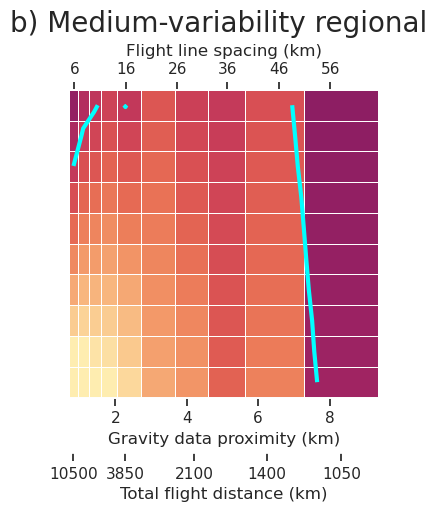

In [31]:
fig = synth_plotting.plot_2var_ensemble(
    sampled_params_df_medium_regional,
    figsize=figsize,
    x="grav_proximity",
    x_title="Gravity data proximity (km)",
    y="grav_noise_levels",
    y_title="Gravity noise (mGal)",
    background="final_inversion_rmse",
    background_title="Bathymetry RMSE (m)",
    background_robust=True,
    plot_contours=contours,
    contour_color="cyan",
    background_cpt_lims=cpt_lims,
    colorbar=False,
    constrained_layout=False,
)
plt.gcf().text(
    0.5, 1.01, "b) Medium-variability regional", fontsize=20, va="bottom", ha="center"
)
ax = fig.get_axes()[0]

# add second x axis with flight line spacing
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
x_tick_vals = df.grav_proximity.unique()
x_tick_labels = df.grav_line_spacing.unique()
x_tick_labels = [int(x) for x in x_tick_labels]
ax2.set_xticks(x_tick_vals)
ax2.set_xticklabels(x_tick_labels)
ax2.grid(False)
ax2.set_xlabel("Flight line spacing (km)")

# add third x axis for flight distance
ax3 = ax.twiny()
ax3.set_xlim(ax.get_xlim())
x_tick_vals = sampled_params_df_medium_regional.grav_proximity.unique()
x_tick_labels = sampled_params_df_medium_regional.flight_kms.unique()
inds_to_remove = [-2, -3, -4, -6, -8]
x_tick_vals = np.delete(x_tick_vals, inds_to_remove)
x_tick_labels = np.delete(x_tick_labels, inds_to_remove)
x_tick_labels = [round(x) for x in x_tick_labels]
ax3.set_xticks(x_tick_vals)
ax3.set_xticklabels(x_tick_labels)
ax3.grid(False)
ax3.set_xlabel("Total flight distance (km)")
ax3.xaxis.set_ticks_position("bottom")
ax3.xaxis.set_label_position("bottom")
ax3.spines["bottom"].set_position(("outward", 40))

ax.yaxis.set_visible(False)

fig.savefig(
    "../paper/figures/Ross_Sea_noise_vs_spacing_medium_regional_2var_supplement.png",
    bbox_inches="tight",
    dpi=300,
)

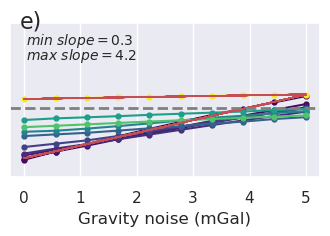

In [24]:
fig = synth_plotting.plot_ensemble_as_lines(
    sampled_params_df_medium_regional,
    figsize=(figsize[0], figsize[1] / 2),
    x="grav_noise_levels",
    x_label="Gravity noise (mGal)",
    y="final_inversion_rmse",
    y_label="Bathymetry RMSE (m)",
    groupby_col="grav_line_spacing",
    cbar_label="Line spacing (km)",
    trend_line=True,
    horizontal_line=contours,
    y_lims=line_plot_ylims,
    colorbar=False,
    slope_min_max=True,
    slope_decimals=1,
)
plt.gcf().text(0.15, 0.95, "e)", fontsize=16, va="top", ha="left")

ax = fig.get_axes()[0]
ax.yaxis.set_visible(False)

plt.savefig(
    "../paper/figures/Ross_Sea_noise_vs_spacing_medium_regional_bathy_error_vs_grav_noise_supplement.png",
    bbox_inches="tight",
    dpi=300,
)

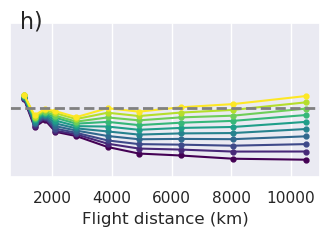

In [25]:
fig = synth_plotting.plot_ensemble_as_lines(
    sampled_params_df_medium_regional,
    figsize=(figsize[0], figsize[1] / 2),
    x="flight_kms",
    x_label="Flight distance (km)",
    y="final_inversion_rmse",
    y_label="Bathymetry RMSE (m)",
    groupby_col="grav_noise_levels",
    cbar_label="Gravity noise (mGal)",
    horizontal_line=contours,
    y_lims=line_plot_ylims,
    colorbar=False,
)
plt.gcf().text(0.15, 0.95, "h)", fontsize=16, va="top", ha="left")

ax = fig.get_axes()[0]

ax.yaxis.set_visible(False)

plt.savefig(
    "../paper/figures/Ross_Sea_noise_vs_spacing_medium_regional_bathy_error_vs_grav_spacing_supplement.png",
    bbox_inches="tight",
    dpi=300,
)

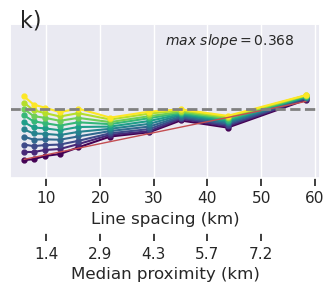

In [172]:
x = "grav_line_spacing"
x2 = "grav_proximity"
fig = synth_plotting.plot_ensemble_as_lines(
    sampled_params_df_medium_regional,
    figsize=(figsize[0], figsize[1] / 2),
    x=x,
    x_label="Line spacing (km)",
    y="final_inversion_rmse",
    y_label="Bathymetry RMSE (m)",
    groupby_col="grav_noise_levels",
    cbar_label="Gravity noise (mGal)",
    horizontal_line=contours,
    y_lims=line_plot_ylims,
    colorbar=False,
    trend_line=True,
    slope_max=True,
    trend_line_text_loc=(0.5, 0.95),
)
plt.gcf().text(0.15, 0.95, "k)", fontsize=16, va="top", ha="left")

ax = fig.get_axes()[0]

df = sampled_params_df_medium_regional[[x2, x]].drop_duplicates()

a, b = df[x].min(), df[x].max()

df = pd.concat([df, pd.DataFrame({x: ax.get_xticks()})]).drop_duplicates(subset=[x])

df = df[df[x].between(a, b)]

df = synthetic.scipy_interp1d(
    df,
    to_interp=x2,
    interp_on=x,
    method="cubic",
)
df = df[df[x].isin(ax.get_xticks())].sort_values(x2)

# add second x axis for line spacing
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())

ax2.set_xticks(df[x])
ax2.set_xticklabels([round(i, 1) for i in df[x2]])
ax2.grid(False)
ax2.set_xlabel("Median proximity (km)")
ax2.xaxis.set_ticks_position("bottom")
ax2.xaxis.set_label_position("bottom")
ax2.spines["bottom"].set_position(("outward", 40))

ax.yaxis.set_visible(False)

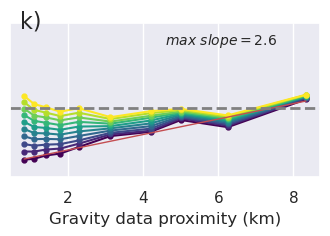

In [26]:
x = "grav_proximity"
fig = synth_plotting.plot_ensemble_as_lines(
    sampled_params_df_medium_regional,
    figsize=(figsize[0], figsize[1] / 2),
    x=x,
    x_label="Gravity data proximity (km)",
    y="final_inversion_rmse",
    y_label="Bathymetry RMSE (m)",
    groupby_col="grav_noise_levels",
    cbar_label="Gravity noise (mGal)",
    horizontal_line=contours,
    y_lims=line_plot_ylims,
    colorbar=False,
    trend_line=True,
    slope_max=True,
    trend_line_text_loc=(0.5, 0.95),
    slope_decimals=1,
)
plt.gcf().text(0.15, 0.95, "k)", fontsize=16, va="top", ha="left")

ax = fig.get_axes()[0]

ax.yaxis.set_visible(False)

plt.savefig(
    "../paper/figures/Ross_Sea_noise_vs_spacing_medium_regional_bathy_error_vs_grav_spacing_2_supplement.png",
    bbox_inches="tight",
    dpi=300,
)

### Strong regional

In [27]:
sampled_params_df_strong_regional[
    [
        "final_inversion_rmse",
        "final_inversion_topo_improvement_rmse",
    ]
].describe()

,final_inversion_rmse,final_inversion_topo_improvement_rmse
count,100.000000,100.000000
mean,22.028173,3.949177
std,4.897815,4.897815
min,11.776672,-7.130729
25%,18.913769,1.572406
50%,22.200469,3.776881
75%,24.404943,7.063580
max,33.108079,14.200677


In [28]:
df = sampled_params_df_strong_regional[
    ["grav_proximity", "grav_line_spacing"]
].drop_duplicates()
df = df.sort_values("grav_line_spacing", ascending=False)
df = pd.concat(
    [
        df,
        pd.DataFrame(
            {
                "grav_line_spacing": np.arange(
                    round(df.grav_line_spacing.min()),
                    round(df.grav_line_spacing.max()) + 1,
                    1,
                )
            }
        ),
    ]
).drop_duplicates(subset="grav_line_spacing")
df = df.sort_values("grav_line_spacing", ascending=False).reset_index(drop=True)

df = synthetic.scipy_interp1d(
    df,
    to_interp="grav_proximity",
    interp_on="grav_line_spacing",
    method="cubic",
)
df = df[["grav_line_spacing", "grav_proximity"]]

df = df[
    df.grav_line_spacing.isin(
        np.arange(
            round(sampled_params_df_strong_regional.grav_line_spacing.min()),
            round(sampled_params_df_strong_regional.grav_line_spacing.max()) + 1,
            10,
        )
    )
]
df

,grav_line_spacing,grav_proximity
3,56.0,8.016317
13,46.0,6.580356
24,36.0,5.139188
35,26.0,3.736880
46,16.0,2.294572
60,6.0,0.851066


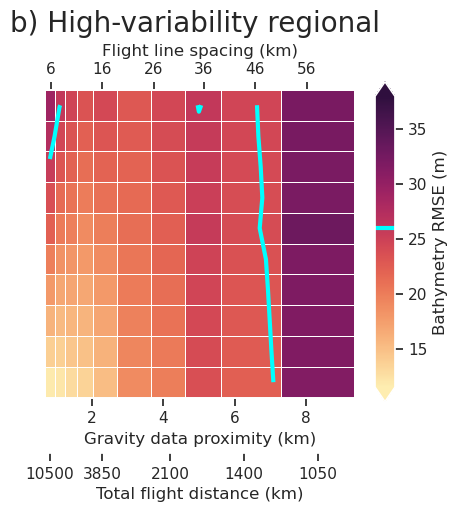

In [32]:
fig = synth_plotting.plot_2var_ensemble(
    sampled_params_df_strong_regional,
    figsize=figsize,
    x="grav_proximity",
    x_title="Gravity data proximity (km)",
    y="grav_noise_levels",
    y_title="Gravity noise (mGal)",
    background="final_inversion_rmse",
    background_title="Bathymetry RMSE (m)",
    background_robust=True,
    plot_contours=contours,
    contour_color="cyan",
    background_cpt_lims=cpt_lims,
    constrained_layout=False,
)
plt.gcf().text(
    0.5, 1.01, "b) High-variability regional", fontsize=20, va="bottom", ha="center"
)
ax = fig.get_axes()[0]

# add second x axis with flight line spacing
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
x_tick_vals = df.grav_proximity.unique()
x_tick_labels = df.grav_line_spacing.unique()
x_tick_labels = [int(x) for x in x_tick_labels]
ax2.set_xticks(x_tick_vals)
ax2.set_xticklabels(x_tick_labels)
ax2.grid(False)
ax2.set_xlabel("Flight line spacing (km)")

# add third x axis for flight distance
ax3 = ax.twiny()
ax3.set_xlim(ax.get_xlim())
x_tick_vals = sampled_params_df_strong_regional.grav_proximity.unique()
x_tick_labels = sampled_params_df_strong_regional.flight_kms.unique()
inds_to_remove = [-2, -3, -4, -6, -8]
x_tick_vals = np.delete(x_tick_vals, inds_to_remove)
x_tick_labels = np.delete(x_tick_labels, inds_to_remove)
x_tick_labels = [round(x) for x in x_tick_labels]
ax3.set_xticks(x_tick_vals)
ax3.set_xticklabels(x_tick_labels)
ax3.grid(False)
ax3.set_xlabel("Total flight distance (km)")
ax3.xaxis.set_ticks_position("bottom")
ax3.xaxis.set_label_position("bottom")
ax3.spines["bottom"].set_position(("outward", 40))

ax.yaxis.set_visible(False)

fig.savefig(
    "../paper/figures/Ross_Sea_noise_vs_spacing_strong_regional_2var.png",
    bbox_inches="tight",
    dpi=300,
)

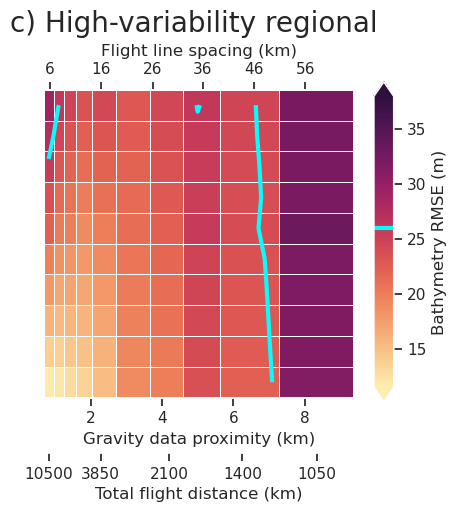

In [33]:
fig = synth_plotting.plot_2var_ensemble(
    sampled_params_df_strong_regional,
    figsize=figsize,
    x="grav_proximity",
    x_title="Gravity data proximity (km)",
    y="grav_noise_levels",
    y_title="Gravity noise (mGal)",
    background="final_inversion_rmse",
    background_title="Bathymetry RMSE (m)",
    background_robust=True,
    plot_contours=contours,
    contour_color="cyan",
    background_cpt_lims=cpt_lims,
    constrained_layout=False,
)
plt.gcf().text(
    0.5, 1.01, "c) High-variability regional", fontsize=20, va="bottom", ha="center"
)
ax = fig.get_axes()[0]

# add second x axis with flight line spacing
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
x_tick_vals = df.grav_proximity.unique()
x_tick_labels = df.grav_line_spacing.unique()
x_tick_labels = [int(x) for x in x_tick_labels]
ax2.set_xticks(x_tick_vals)
ax2.set_xticklabels(x_tick_labels)
ax2.grid(False)
ax2.set_xlabel("Flight line spacing (km)")

# add third x axis for flight distance
ax3 = ax.twiny()
ax3.set_xlim(ax.get_xlim())
x_tick_vals = sampled_params_df_strong_regional.grav_proximity.unique()
x_tick_labels = sampled_params_df_strong_regional.flight_kms.unique()
inds_to_remove = [-2, -3, -4, -6, -8]
x_tick_vals = np.delete(x_tick_vals, inds_to_remove)
x_tick_labels = np.delete(x_tick_labels, inds_to_remove)
x_tick_labels = [round(x) for x in x_tick_labels]
ax3.set_xticks(x_tick_vals)
ax3.set_xticklabels(x_tick_labels)
ax3.grid(False)
ax3.set_xlabel("Total flight distance (km)")
ax3.xaxis.set_ticks_position("bottom")
ax3.xaxis.set_label_position("bottom")
ax3.spines["bottom"].set_position(("outward", 40))

ax.yaxis.set_visible(False)

fig.savefig(
    "../paper/figures/Ross_Sea_noise_vs_spacing_strong_regional_2var_supplement.png",
    bbox_inches="tight",
    dpi=300,
)

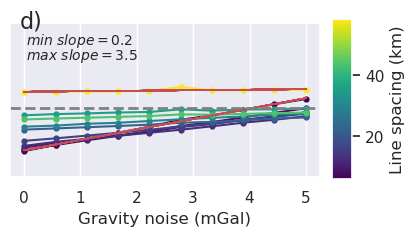

In [34]:
fig = synth_plotting.plot_ensemble_as_lines(
    sampled_params_df_strong_regional,
    figsize=(figsize[0], figsize[1] / 2),
    x="grav_noise_levels",
    x_label="Gravity noise (mGal)",
    y="final_inversion_rmse",
    y_label="Bathymetry RMSE (m)",
    groupby_col="grav_line_spacing",
    cbar_label="Line spacing (km)",
    trend_line=True,
    horizontal_line=contours,
    y_lims=line_plot_ylims,
    slope_min_max=True,
    slope_decimals=1,
)
plt.gcf().text(0.15, 0.95, "d)", fontsize=16, va="top", ha="left")

ax = fig.get_axes()[0]
ax.yaxis.set_visible(False)

plt.savefig(
    "../paper/figures/Ross_Sea_noise_vs_spacing_strong_regional_bathy_error_vs_grav_noise.png",
    bbox_inches="tight",
    dpi=300,
)

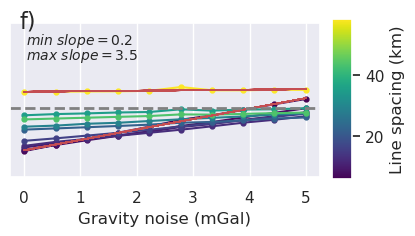

In [35]:
fig = synth_plotting.plot_ensemble_as_lines(
    sampled_params_df_strong_regional,
    figsize=(figsize[0], figsize[1] / 2),
    x="grav_noise_levels",
    x_label="Gravity noise (mGal)",
    y="final_inversion_rmse",
    y_label="Bathymetry RMSE (m)",
    groupby_col="grav_line_spacing",
    cbar_label="Line spacing (km)",
    trend_line=True,
    horizontal_line=contours,
    y_lims=line_plot_ylims,
    slope_min_max=True,
    slope_decimals=1,
)
plt.gcf().text(0.15, 0.95, "f)", fontsize=16, va="top", ha="left")

ax = fig.get_axes()[0]
ax.yaxis.set_visible(False)

plt.savefig(
    "../paper/figures/Ross_Sea_noise_vs_spacing_strong_regional_bathy_error_vs_grav_noise_supplement.png",
    bbox_inches="tight",
    dpi=300,
)

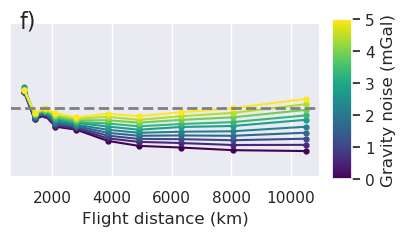

In [36]:
fig = synth_plotting.plot_ensemble_as_lines(
    sampled_params_df_strong_regional,
    figsize=(figsize[0], figsize[1] / 2),
    x="flight_kms",
    x_label="Flight distance (km)",
    y="final_inversion_rmse",
    y_label="Bathymetry RMSE (m)",
    groupby_col="grav_noise_levels",
    cbar_label="Gravity noise (mGal)",
    horizontal_line=contours,
    y_lims=line_plot_ylims,
)
plt.gcf().text(0.15, 0.95, "f)", fontsize=16, va="top", ha="left")

ax = fig.get_axes()[0]

ax.yaxis.set_visible(False)

plt.savefig(
    "../paper/figures/Ross_Sea_noise_vs_spacing_strong_regional_bathy_error_vs_grav_spacing.png",
    bbox_inches="tight",
    dpi=300,
)

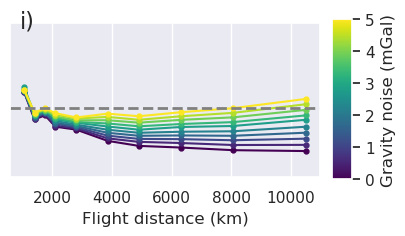

In [37]:
fig = synth_plotting.plot_ensemble_as_lines(
    sampled_params_df_strong_regional,
    figsize=(figsize[0], figsize[1] / 2),
    x="flight_kms",
    x_label="Flight distance (km)",
    y="final_inversion_rmse",
    y_label="Bathymetry RMSE (m)",
    groupby_col="grav_noise_levels",
    cbar_label="Gravity noise (mGal)",
    horizontal_line=contours,
    y_lims=line_plot_ylims,
)
plt.gcf().text(0.15, 0.95, "i)", fontsize=16, va="top", ha="left")

ax = fig.get_axes()[0]

ax.yaxis.set_visible(False)

plt.savefig(
    "../paper/figures/Ross_Sea_noise_vs_spacing_strong_regional_bathy_error_vs_grav_spacing_supplement.png",
    bbox_inches="tight",
    dpi=300,
)

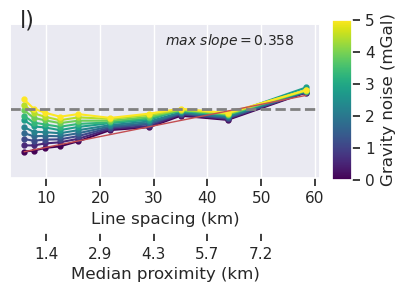

In [179]:
x = "grav_line_spacing"
x2 = "grav_proximity"
fig = synth_plotting.plot_ensemble_as_lines(
    sampled_params_df_strong_regional,
    figsize=(figsize[0], figsize[1] / 2),
    x=x,
    x_label="Line spacing (km)",
    y="final_inversion_rmse",
    y_label="Bathymetry RMSE (m)",
    groupby_col="grav_noise_levels",
    cbar_label="Gravity noise (mGal)",
    horizontal_line=contours,
    y_lims=line_plot_ylims,
    trend_line=True,
    slope_max=True,
    trend_line_text_loc=(0.5, 0.95),
)
plt.gcf().text(0.15, 0.95, "l)", fontsize=16, va="top", ha="left")

ax = fig.get_axes()[0]

df = sampled_params_df_strong_regional[[x2, x]].drop_duplicates()

a, b = df[x].min(), df[x].max()

df = pd.concat([df, pd.DataFrame({x: ax.get_xticks()})]).drop_duplicates(subset=[x])

df = df[df[x].between(a, b)]

df = synthetic.scipy_interp1d(
    df,
    to_interp=x2,
    interp_on=x,
    method="cubic",
)
df = df[df[x].isin(ax.get_xticks())].sort_values(x2)

# add second x axis for line spacing
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())

ax2.set_xticks(df[x])
ax2.set_xticklabels([round(i, 1) for i in df[x2]])
ax2.grid(False)
ax2.set_xlabel("Median proximity (km)")
ax2.xaxis.set_ticks_position("bottom")
ax2.xaxis.set_label_position("bottom")
ax2.spines["bottom"].set_position(("outward", 40))

ax.yaxis.set_visible(False)

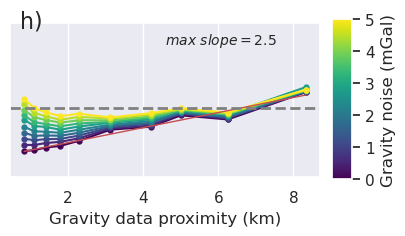

In [38]:
x = "grav_proximity"
fig = synth_plotting.plot_ensemble_as_lines(
    sampled_params_df_strong_regional,
    figsize=(figsize[0], figsize[1] / 2),
    x=x,
    x_label="Gravity data proximity (km)",
    y="final_inversion_rmse",
    y_label="Bathymetry RMSE (m)",
    groupby_col="grav_noise_levels",
    cbar_label="Gravity noise (mGal)",
    horizontal_line=contours,
    y_lims=line_plot_ylims,
    trend_line=True,
    slope_max=True,
    trend_line_text_loc=(0.5, 0.95),
    slope_decimals=1,
)
plt.gcf().text(0.15, 0.95, "h)", fontsize=16, va="top", ha="left")

ax = fig.get_axes()[0]

ax.yaxis.set_visible(False)

plt.savefig(
    "../paper/figures/Ross_Sea_noise_vs_spacing_strong_regional_bathy_error_vs_grav_spacing_2.png",
    bbox_inches="tight",
    dpi=300,
)

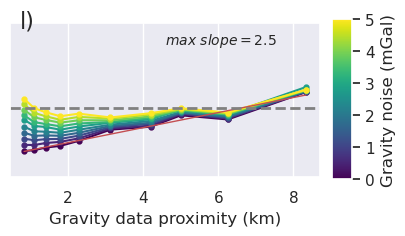

In [39]:
x = "grav_proximity"
fig = synth_plotting.plot_ensemble_as_lines(
    sampled_params_df_strong_regional,
    figsize=(figsize[0], figsize[1] / 2),
    x=x,
    x_label="Gravity data proximity (km)",
    y="final_inversion_rmse",
    y_label="Bathymetry RMSE (m)",
    groupby_col="grav_noise_levels",
    cbar_label="Gravity noise (mGal)",
    horizontal_line=contours,
    y_lims=line_plot_ylims,
    trend_line=True,
    slope_max=True,
    trend_line_text_loc=(0.5, 0.95),
    slope_decimals=1,
)
plt.gcf().text(0.15, 0.95, "l)", fontsize=16, va="top", ha="left")

ax = fig.get_axes()[0]

ax.yaxis.set_visible(False)

plt.savefig(
    "../paper/figures/Ross_Sea_noise_vs_spacing_strong_regional_bathy_error_vs_grav_spacing_2_supplement.png",
    bbox_inches="tight",
    dpi=300,
)